# Чекпойнт 6


## Контекст

В чекпойнте 5 на pre-match задаче DL-архитектуры проиграли GradientBoosting, так как pre-match признаки почти линейно сепарабельны.

В чекпойнте 6 трек DL переносится на in-play (live) предсказание победителя по последовательности уже сыгранных розыгрышей. У задачи есть последовательная структура  её не видят табличные модели, и здесь DL должен иметь преимущество.

**Опорные работы.**
- DeepTennis (Lerner, Badri, Monogue, Stanford CS230, 2019) — LSTM, BCE с финальной меткой.
- ATennision (Lu, HSET 105, 2024) — Transformer-encoder для real-time win probability.
- Yu & Gao (HSET 140, 2025) — Transformer + явные momentum-фичи.


## Постановка in-play задачи

- **Вход:** префикс матча — последовательность point-level векторов длиной t.
- **Выход:** калиброванная вероятность $P(\text{player1 win})$ после каждого розыгрыша.
- **Loss:** BCE с финальной меткой матча на каждом шаге, **с позиционным взвешиванием**:

  $$\text{weight}_t = (t / T)^{\alpha}, \quad \mathcal{L} = \frac{1}{B} \sum_{b} \frac{1}{T_b} \sum_{t=1}^{T_b} \text{weight}_t \cdot \text{BCE}(p_t, y)$$

  где $\alpha$ — гиперпараметр (стартовое 0.5, контроль $\alpha=0$ — равный вес как в DeepTennis).
- **Сплит:** train ≤ 2020, val = 2021, test = 2022–2024.
- **Метрики:** log-loss, Brier score, accuracy, ROC-AUC на префиксах 25% / 50% / 75% / 100% (по `floor(p · T_i)` на матч), 4 калибровочные кривые (отдельно по фазам).


## 1. Setup & imports

In [1]:
from __future__ import annotations

import gc
import math
import re
import time
from dataclasses import dataclass, field
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss, accuracy_score,
)
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch={torch.__version__}, device={DEVICE}, cuda_avail={torch.cuda.is_available()}")

ROOT = Path.cwd()
PBP_SLAM_DIR = ROOT / "DATASETS" / "pbp_slam"
NORM_DF_PATH = ROOT / "norm_dataframe.csv"
ATP_MATCHES_DIR = ROOT / "DATASETS"
CHECKPOINT5_RESULTS = ROOT / "checkpoint5_results.csv"
CACHE_DIR = ROOT / "DATASETS" / "checkpoint6_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

torch=2.5.1+cu121, device=cuda, cuda_avail=True


## 2. Парсинг pbp Slam point-by-point

  Данные пары файлов `YYYY-{slam}-matches.csv` (метаданные) + `YYYY-{slam}-points.csv` (точки) для каждого Grand Slam.

  **Результаты разведки данных.** Колонка `winner` в `*-matches.csv` пустая везде, поэтому победителя восстанавливаю из последнего розыгрыша (`PointWinner`) он заполнен.

  **Оставляю только мужские матчи**

  **Итог:** 5 336 матчей (train ≤ 2020 ≈ 4 050, val 2021 ≈ 505, test 2022–2024 ≈ 757). Результат парсинга кэширую в parquet.

In [2]:
SLAM_SURFACE = {
    "ausopen": "Hard",
    "frenchopen": "Clay",
    "usopen": "Hard",
    "wimbledon": "Grass",
}

POINTS_KEEP_COLS = [
    "match_id", "SetNo", "GameNo", "PointNumber",
    "PointServer", "PointWinner", "SetWinner", "GameWinner",
    "P1GamesWon", "P2GamesWon", "P1Score", "P2Score",
    "P1PointsWon", "P2PointsWon",
    "P1Ace", "P2Ace", "P1DoubleFault", "P2DoubleFault",
    "P1Winner", "P2Winner", "P1UnfErr", "P2UnfErr",
    "P1BreakPoint", "P2BreakPoint", "P1BreakPointWon", "P2BreakPointWon",
    "P1FirstSrvIn", "P2FirstSrvIn", "P1FirstSrvWon", "P2FirstSrvWon",
    "P1SecondSrvIn", "P2SecondSrvIn", "P1SecondSrvWon", "P2SecondSrvWon",
    "RallyCount", "ServeIndicator",
]


def _list_singles_pairs(pbp_dir: Path) -> list[tuple[Path, Path, int, str]]:
    pairs = []
    for m_path in sorted(pbp_dir.glob("*-matches.csv")):
        if "-doubles" in m_path.name or "-mixed" in m_path.name:
            continue
        stem = m_path.name.replace("-matches.csv", "")
        try:
            year_str, slam = stem.split("-", 1)
            year = int(year_str)
        except ValueError:
            continue
        p_path = pbp_dir / f"{stem}-points.csv"
        if not p_path.exists():
            continue
        pairs.append((m_path, p_path, year, slam))
    return pairs


def _is_warmup_point(pn) -> bool:
    if pd.isna(pn):
        return True
    s = str(pn)
    return s.endswith("X") or s.endswith("Y") or s == "0"


def _parse_one_tournament(matches_path, points_path, slam):
    matches = pd.read_csv(matches_path, low_memory=False)
    points = pd.read_csv(points_path, low_memory=False)

    for col in POINTS_KEEP_COLS:
        if col not in points.columns:
            points[col] = pd.NA
    points = points[POINTS_KEEP_COLS].copy()

    warmup_mask = points["PointNumber"].apply(_is_warmup_point)
    points = points.loc[~warmup_mask].copy()
    points = points[(points["PointWinner"].isin([1, 2])) & (points["PointServer"].isin([1, 2]))].copy()
    if points.empty:
        return points, pd.DataFrame()

    points = points.reset_index(drop=True)
    points["point_idx"] = points.groupby("match_id").cumcount()
    points = points.drop(columns=["PointNumber"])

    for c in ["P1Score", "P2Score"]:
        points[c] = points[c].astype("string")
    num_cols = [c for c in points.columns
                if c not in ("match_id", "P1Score", "P2Score", "point_idx")]
    for c in num_cols:
        points[c] = pd.to_numeric(points[c], errors="coerce")

    match_meta = matches[["match_id", "year", "slam", "match_num", "player1", "player2"]].copy()
    match_meta["match_num"] = match_meta["match_num"].astype(str)

    last_pw = points.groupby("match_id")["PointWinner"].last().rename("winner_idx").astype("Int64")
    n_points = points.groupby("match_id").size().rename("n_points")
    sets_played = points.groupby("match_id")["SetNo"].max().rename("sets_played").astype("Int64")

    match_meta = (match_meta
                  .merge(n_points, left_on="match_id", right_index=True, how="inner")
                  .merge(last_pw, left_on="match_id", right_index=True, how="inner")
                  .merge(sets_played, left_on="match_id", right_index=True, how="inner"))

    match_meta["surface"] = SLAM_SURFACE.get(slam, "Hard")
    mn_upper = match_meta["match_num"].str.upper()
    match_meta["is_mens"] = mn_upper.str.startswith("1") | mn_upper.str.startswith("MS")
    match_meta["best_of"] = np.where(match_meta["is_mens"], 5, 3)

    return points, match_meta


def parse_pbp_slam(pbp_dir: Path):
    pairs = _list_singles_pairs(pbp_dir)
    print(f"Found {len(pairs)} singles tournament file pairs")

    all_points, all_meta = [], []
    t0 = time.time()
    for i, (m_path, p_path, year, slam) in enumerate(pairs):
        try:
            pts, meta = _parse_one_tournament(m_path, p_path, slam)
        except Exception as e:
            print(f"  [skip] {m_path.name}: {e}")
            continue
        if not pts.empty:
            all_points.append(pts)
            all_meta.append(meta)
        if (i + 1) % 10 == 0:
            print(f"  parsed {i + 1}/{len(pairs)} ({time.time() - t0:.1f}s)")
    points_df = pd.concat(all_points, ignore_index=True)
    meta_df = pd.concat(all_meta, ignore_index=True)
    print(f"Total: {len(meta_df):,} matches, {len(points_df):,} points ({time.time() - t0:.1f}s)")
    return points_df, meta_df

In [3]:
POINTS_CACHE = CACHE_DIR / "pbp_slam_points.parquet"
META_CACHE = CACHE_DIR / "pbp_slam_meta.parquet"

if POINTS_CACHE.exists() and META_CACHE.exists():
    points_df = pd.read_parquet(POINTS_CACHE)
    meta_df = pd.read_parquet(META_CACHE)
    print(f"loaded from cache: {len(meta_df):,} matches, {len(points_df):,} points")
else:
    points_df, meta_df = parse_pbp_slam(PBP_SLAM_DIR)
    points_df.to_parquet(POINTS_CACHE, index=False)
    meta_df.to_parquet(META_CACHE, index=False)
    print(f"saved to {POINTS_CACHE.name}, {META_CACHE.name}")

# Оставляем только мужские матчи

n_before = len(meta_df)
meta_df = meta_df[meta_df["is_mens"]].reset_index(drop=True)
points_df = points_df[points_df["match_id"].isin(meta_df["match_id"])].reset_index(drop=True)
print(f"\nfiltered to mens-only: {n_before:,} -> {len(meta_df):,} matches, {len(points_df):,} points")

loaded from cache: 10,508 matches, 1,910,897 points

filtered to mens-only: 10,508 -> 5,336 matches, 1,187,528 points

=== meta sample ===
            match_id  year     slam match_num        player1        player2  n_points  winner_idx  sets_played surface  is_mens  best_of
0  2011-ausopen-1101  2011  ausopen      1101   Rafael Nadal  Marcos Daniel        61           1            2    Hard     True        5
1  2011-ausopen-1103  2011  ausopen      1103  Bernard Tomic  Jeremy Chardy       184           1            3    Hard     True        5
2  2011-ausopen-1105  2011  ausopen      1105     John Isner  Florent Serra       198           1            3    Hard     True        5

=== meta describe ===
              year     n_points  sets_played  best_of
count  5336.000000  5336.000000       5336.0   5336.0
mean   2017.293666   222.550225     3.645615      5.0
std       3.703865    64.974739     0.804726      0.0
min    2011.000000     4.000000          1.0      5.0
25%    2014.000000  

## 3. Признаки на каждый розыгрыш

Удалил колонки в которых много пропусков

**Финальный feature set (17 штук на розыгрыш):**

| # | Имя | Описание |
|---|-----|---------|
| 1-2 | `p{1,2}_sets` | сеты, выигранные игроком до этого розыгрыша |
| 3-4 | `p{1,2}_games` | геймы в текущем сете |
| 5-6 | `p{1,2}_pts_in_game` | очки в текущем гейме (0/1/2/3+, в т.ч. в тай-брейке) |
| 7 | `is_tiebreak` | флаг тай-брейка (геймы 6-6) |
| 8 | `p1_serving` | бинарный: подаёт ли P1 сейчас |
| 9-12 | `p{1,2}_{aces,dfs}_cum` | кумулятивные эйсы и двойные ошибки |
| 13-14 | `p{1,2}_pts_won_cum` | кумулятивные очки в матче (≈ длина истории до сейчас) |
| 15-16 | `p1_last{5,10}` | доля последних 5/10 розыгрышей, выигранных P1 |
| 17 | `streak_signed` | текущая серия: +k = P1 выиграл подряд k, -k = P2 |


Все признаки вычисляются до текущего розыгрыша, чтобы не было утечки.

In [5]:
FEATURE_NAMES = [
    "p1_sets", "p2_sets",
    "p1_games", "p2_games",
    "p1_pts_in_game", "p2_pts_in_game",
    "is_tiebreak",
    "p1_serving",
    "p1_aces_cum", "p2_aces_cum",
    "p1_dfs_cum", "p2_dfs_cum",
    "p1_pts_won_cum", "p2_pts_won_cum",
    "p1_last5", "p1_last10",
    "streak_signed",
]


def build_match_features(m_pts: pd.DataFrame) -> np.ndarray:
    n = len(m_pts)
    if n == 0:
        return np.zeros((0, len(FEATURE_NAMES)), dtype=np.float32)

    pw = m_pts["PointWinner"].to_numpy(dtype=np.int8)
    ps = m_pts["PointServer"].to_numpy(dtype=np.int8)
    sn = m_pts["SetNo"].to_numpy(dtype=np.int16)
    gn = m_pts["GameNo"].to_numpy(dtype=np.int16)
    p1a = m_pts["P1Ace"].fillna(0).to_numpy(dtype=np.int8)
    p2a = m_pts["P2Ace"].fillna(0).to_numpy(dtype=np.int8)
    p1d = m_pts["P1DoubleFault"].fillna(0).to_numpy(dtype=np.int8)
    p2d = m_pts["P2DoubleFault"].fillna(0).to_numpy(dtype=np.int8)

    p1_sets = np.zeros(n, dtype=np.int16)
    p2_sets = np.zeros(n, dtype=np.int16)
    p1_games = np.zeros(n, dtype=np.int16)
    p2_games = np.zeros(n, dtype=np.int16)
    p1_pig = np.zeros(n, dtype=np.int16)
    p2_pig = np.zeros(n, dtype=np.int16)
    streak = np.zeros(n, dtype=np.int16)
    last5 = np.full(n, 0.5, dtype=np.float32)
    last10 = np.full(n, 0.5, dtype=np.float32)

    s1 = s2 = g1 = g2 = pp1 = pp2 = 0
    cur_set = int(sn[0])
    cur_game = int(gn[0])
    str_ = 0
    buf5: list[int] = []
    buf10: list[int] = []

    for i in range(n):
        # Проверяем, изменились ли SetNo / GameNo с прошлого шага.
        # Если SetNo изменился закрываем предыдущий гейм И сет.
        # Если только GameNo закрываем гейм.
        if sn[i] != cur_set:
            if i > 0:
                if pw[i - 1] == 1:
                    g1 += 1
                else:
                    g2 += 1
            if g1 > g2:
                s1 += 1
            else:
                s2 += 1
            g1, g2, pp1, pp2 = 0, 0, 0, 0
            cur_set = int(sn[i])
            cur_game = int(gn[i])
        elif gn[i] != cur_game:
            if i > 0:
                if pw[i - 1] == 1:
                    g1 += 1
                else:
                    g2 += 1
            pp1, pp2 = 0, 0
            cur_game = int(gn[i])

        # Запись СОСТОЯНИЯ ДО текущей точки.
        p1_sets[i] = s1
        p2_sets[i] = s2
        p1_games[i] = g1
        p2_games[i] = g2
        p1_pig[i] = pp1
        p2_pig[i] = pp2
        streak[i] = str_
        if buf5:
            last5[i] = sum(buf5) / len(buf5)
        if buf10:
            last10[i] = sum(buf10) / len(buf10)

        won_by_p1 = pw[i] == 1
        if won_by_p1:
            pp1 += 1
            str_ = max(str_, 0) + 1
        else:
            pp2 += 1
            str_ = min(str_, 0) - 1

        v = 1 if won_by_p1 else 0
        buf5.append(v)
        if len(buf5) > 5:
            buf5.pop(0)
        buf10.append(v)
        if len(buf10) > 10:
            buf10.pop(0)

    # Кумулятивы ДО текущей точки
    def _cum_shift(x):
        out = np.zeros(n, dtype=np.int16)
        if n > 1:
            out[1:] = np.cumsum(x)[:-1]
        return out

    cs_p1a = _cum_shift(p1a)
    cs_p2a = _cum_shift(p2a)
    cs_p1d = _cum_shift(p1d)
    cs_p2d = _cum_shift(p2d)
    cs_p1pts = _cum_shift((pw == 1).astype(np.int16))
    cs_p2pts = _cum_shift((pw == 2).astype(np.int16))

    p1_serving = (ps == 1).astype(np.int8)
    is_tiebreak = ((p1_games == 6) & (p2_games == 6)).astype(np.int8)

    feats = np.column_stack([
        p1_sets, p2_sets,
        p1_games, p2_games,
        p1_pig, p2_pig,
        is_tiebreak,
        p1_serving,
        cs_p1a, cs_p2a, cs_p1d, cs_p2d,
        cs_p1pts, cs_p2pts,
        last5, last10,
        streak,
    ]).astype(np.float32)
    return feats


def build_all_features(points_df: pd.DataFrame, meta_df: pd.DataFrame) -> dict:
    """Собирает признаки и labels для каждого матча."""
    pts_sorted = points_df.sort_values(["match_id", "point_idx"], kind="mergesort")
    grouped = pts_sorted.groupby("match_id", sort=False)
    feats_by_id: dict[str, np.ndarray] = {}
    labels: list[float] = []
    match_ids: list[str] = []
    label_map = meta_df.set_index("match_id")["winner_idx"].to_dict()

    t0 = time.time()
    for j, (mid, g) in enumerate(grouped):
        feats = build_match_features(g)
        feats_by_id[mid] = feats
        labels.append(1.0 if label_map[mid] == 1 else 0.0)
        match_ids.append(mid)
        if (j + 1) % 1000 == 0:
            print(f"  built {j + 1:,} matches ({time.time() - t0:.1f}s)")
    print(f"Done: {len(match_ids):,} matches in {time.time() - t0:.1f}s")
    return {"feats": feats_by_id, "labels": np.asarray(labels, dtype=np.float32),
            "match_ids": match_ids}


FEATS_CACHE = CACHE_DIR / "match_features.npz"

if FEATS_CACHE.exists():
    z = np.load(FEATS_CACHE, allow_pickle=True)
    match_ids = list(z["match_ids"])
    labels = z["labels"]
    feats_by_id = {mid: z[f"f_{i}"] for i, mid in enumerate(match_ids)}
    print(f"loaded features from cache: {len(match_ids):,} matches")
else:
    out = build_all_features(points_df, meta_df)
    feats_by_id = out["feats"]
    labels = out["labels"]
    match_ids = out["match_ids"]
    save_dict = {"match_ids": np.asarray(match_ids), "labels": labels}
    for i, mid in enumerate(match_ids):
        save_dict[f"f_{i}"] = feats_by_id[mid]
    np.savez_compressed(FEATS_CACHE, **save_dict)
    print(f"saved features to {FEATS_CACHE.name}")

loaded features from cache: 5,336 matches


## 4. Pre-match priors, сплит по годам и тензоры

В этом разделе я собрал входные тензоры для моделей. Сначала пришлось соединить три источника. У меня pbp с именами игроков, а priors из чекпойнта 5 лежат по ID. Я взял atp_matches.csv как мост там есть и то и другое.

 Дальше сплит сделал по годам, а не random, так как при random была бы утечка.

Потом тензоризация. T_max взял как 95-й перцентиль длины, а не абсолютный максимум иначе на редких длинных матчах GPU гонял бы пустой padding. StandardScaler обучил
только на train, чтобы val/test не утекли через нормализацию.

Матчи, где не получилось вытащить хоть один из 10 priors, выбросил целиком (потеря ~3%). Imputation не делал так как датасет маленький

In [7]:
PRIOR_FEATURE_COLS = [
    "ELO_DIFF", "ELO_SURFACE_DIFF", "ELO_GRAD_50_DIFF",
    "ATP_RANK_DIFF", "AGE_DIFF", "HEIGHT_DIFF",
    "H2H_DIFF", "H2H_SURFACE_DIFF",
    "P_WIN_LAST_2000_DIFF", "P_ACE_LAST_2000_DIFF",
]

ATP_SLAM_NAME_MAP = {
    "Australian Open": "ausopen",
    "Roland Garros": "frenchopen",
    "Wimbledon": "wimbledon",
    "Us Open": "usopen",
    "US Open": "usopen",
}


def _last_name(s) -> str:
    if pd.isna(s):
        return ""
    parts = str(s).strip().split()
    return parts[-1].lower() if parts else ""


def load_atp_slams(years: range) -> pd.DataFrame:
    """Грузит и фильтрует ATP-матчи за указанные годы."""
    frames = []
    for y in years:
        p = ATP_MATCHES_DIR / f"atp_matches_{y}.csv"
        if p.exists():
            frames.append(pd.read_csv(p, low_memory=False))
    atp = pd.concat(frames, ignore_index=True)
    atp = atp[atp["tourney_level"] == "G"].copy()
    atp["slam"] = atp["tourney_name"].map(ATP_SLAM_NAME_MAP)
    atp = atp.dropna(subset=["slam"])
    atp["year"] = pd.to_datetime(atp["tourney_date"].astype(str), format="%Y%m%d").dt.year
    atp["w_last"] = atp["winner_name"].apply(_last_name)
    atp["l_last"] = atp["loser_name"].apply(_last_name)

    atp["key"] = list(zip(atp["year"], atp["slam"],
                          atp.apply(lambda r: frozenset({r["w_last"], r["l_last"]}), axis=1)))

    atp = atp.drop_duplicates(subset=["key"], keep="first")
    return atp


atp_slam = load_atp_slams(range(2011, 2025))
print(f"ATP slam matches loaded: {len(atp_slam):,}")
print(f"  unique keys: {atp_slam['key'].nunique():,}")
print(f"  by year: {atp_slam.groupby('year').size().to_dict()}")

ATP slam matches loaded: 6,982
  unique keys: 6,982
  by year: {2011: 508, 2012: 508, 2013: 507, 2014: 507, 2015: 508, 2016: 508, 2017: 508, 2018: 507, 2019: 508, 2020: 381, 2021: 508, 2022: 508, 2023: 508, 2024: 508}


In [8]:
def join_priors(meta_df: pd.DataFrame, atp_slam: pd.DataFrame, norm_path: Path) -> pd.DataFrame:
    m = meta_df.copy()
    m["p1_last"] = m["player1"].apply(_last_name)
    m["p2_last"] = m["player2"].apply(_last_name)
    m["key"] = list(zip(m["year"], m["slam"],
                        m.apply(lambda r: frozenset({r["p1_last"], r["p2_last"]}), axis=1)))

    atp_min = atp_slam[["key", "winner_id", "loser_id", "tourney_date",
                        "winner_name", "loser_name", "w_last"]].copy()
    j = m.merge(atp_min, on="key", how="left")

    matched_atp = j["winner_id"].notna()

    j["pbp_winner_last"] = np.where(j["winner_idx"] == 1, j["p1_last"], j["p2_last"])
    name_ok = j["w_last"].astype(str) == j["pbp_winner_last"].astype(str)
    j.loc[matched_atp & ~name_ok, ["winner_id", "loser_id", "tourney_date"]] = np.nan

    j["p1_id"] = np.where(j["winner_idx"] == 1, j["winner_id"], j["loser_id"])
    j["p2_id"] = np.where(j["winner_idx"] == 1, j["loser_id"], j["winner_id"])

    norm = pd.read_csv(norm_path)
    norm["tourney_date_int"] = pd.to_datetime(norm["tourney_date"]).dt.strftime("%Y%m%d").astype(int)
    norm = norm[["tourney_date_int", "PLAYER_1", "PLAYER_2"] + PRIOR_FEATURE_COLS].copy()
    norm = norm.dropna(subset=PRIOR_FEATURE_COLS).reset_index(drop=True)
    keys_arr = list(zip(norm["tourney_date_int"].astype(int).to_numpy(),
                        norm["PLAYER_1"].astype(int).to_numpy(),
                        norm["PLAYER_2"].astype(int).to_numpy()))
    vals_arr = norm[PRIOR_FEATURE_COLS].to_numpy(dtype=np.float32)
    norm_lookup: dict[tuple, np.ndarray] = dict(zip(keys_arr, vals_arr))

    prior_rows = np.full((len(j), len(PRIOR_FEATURE_COLS)), np.nan, dtype=np.float32)
    found = 0
    flipped = 0
    p1_arr = j["p1_id"].to_numpy()
    p2_arr = j["p2_id"].to_numpy()
    td_arr = j["tourney_date"].to_numpy()
    for i in range(len(j)):
        if pd.isna(p1_arr[i]) or pd.isna(p2_arr[i]) or pd.isna(td_arr[i]):
            continue
        td_i = int(td_arr[i]);
        p1_i = int(p1_arr[i]);
        p2_i = int(p2_arr[i])
        v = norm_lookup.get((td_i, p1_i, p2_i))
        if v is not None:
            prior_rows[i] = v
            found += 1
            continue
        v = norm_lookup.get((td_i, p2_i, p1_i))
        if v is not None:
            prior_rows[i] = -v
            found += 1
            flipped += 1

    for k, col in enumerate(PRIOR_FEATURE_COLS):
        j[col] = prior_rows[:, k]
    j["has_prior"] = ~np.isnan(prior_rows).any(axis=1)
    return j


meta_with_priors = join_priors(meta_df, atp_slam, NORM_DF_PATH)

ATP join: 5,188 / 5,336 (97.2%)
  winner-name verified: 5,166 (96.8%)
norm_df entries: 95,356
norm_df join: 5,152 / 5,336 (96.6%), flipped 2,517

=== Final coverage ===
matches with priors: 5,152 / 5,336 (96.6%)

=== Priors stats (matched only, P1-perspective) ===
                       mean      std       min       max
ELO_DIFF              3.618  282.750  -913.032   967.048
ELO_SURFACE_DIFF      1.545  259.024  -895.419   855.034
ELO_GRAD_50_DIFF      0.398  122.819  -507.214   547.409
ATP_RANK_DIFF         0.933  112.088 -1280.000  1068.000
AGE_DIFF             -0.116    5.913   -20.900    20.100
HEIGHT_DIFF           0.073   10.175   -38.000    35.000
H2H_DIFF              0.223    5.750   -44.000    53.000
H2H_SURFACE_DIFF      0.090    3.329   -32.000    35.000
P_WIN_LAST_2000_DIFF  0.002    0.208    -0.828     0.821
P_ACE_LAST_2000_DIFF  0.076    4.469   -21.278    18.057

=== Coverage by year ===
      sum  count   mean
year                   
2011  323    335  0.964
2012  330 

In [9]:
def split_and_tensorize(meta_with_priors: pd.DataFrame,
                        feats_by_id: dict[str, np.ndarray]
                        ) -> dict[str, dict[str, np.ndarray]]:
    valid = meta_with_priors[meta_with_priors["has_prior"]].copy()
    valid = valid.reset_index(drop=True)

    train_mask = valid["year"] <= 2020
    val_mask = valid["year"] == 2021
    test_mask = (valid["year"] >= 2022) & (valid["year"] <= 2024)

    sub_train = valid[train_mask].reset_index(drop=True)
    sub_val = valid[val_mask].reset_index(drop=True)
    sub_test = valid[test_mask].reset_index(drop=True)

    # Глобальный T_max
    T_max = int(valid["n_points"].max())
    F_seq = len(FEATURE_NAMES)
    F_prior = len(PRIOR_FEATURE_COLS)
    print(f"T_max={T_max}, F_seq={F_seq}, F_prior={F_prior}")

    # Фит StandardScaler на train
    train_flat = np.concatenate(
        [feats_by_id[mid] for mid in sub_train["match_id"]], axis=0
    ).astype(np.float32)
    seq_scaler = StandardScaler()
    seq_scaler.fit(train_flat)

    train_prior = sub_train[PRIOR_FEATURE_COLS].to_numpy(dtype=np.float32)
    prior_scaler = StandardScaler()
    prior_scaler.fit(train_prior)

    def _build(sub: pd.DataFrame) -> dict:
        n = len(sub)
        X = np.zeros((n, T_max, F_seq), dtype=np.float32)
        mask = np.zeros((n, T_max), dtype=np.bool_)
        lengths = np.zeros(n, dtype=np.int32)
        for i, mid in enumerate(sub["match_id"].values):
            f = feats_by_id[mid].astype(np.float32)
            T_i = min(f.shape[0], T_max)
            X[i, :T_i] = seq_scaler.transform(f[:T_i])
            mask[i, :T_i] = True
            lengths[i] = T_i
        prior = prior_scaler.transform(
            sub[PRIOR_FEATURE_COLS].to_numpy(dtype=np.float32)
        ).astype(np.float32)
        y = (sub["winner_idx"] == 1).astype(np.float32).to_numpy()
        return {"X": X, "mask": mask, "prior": prior, "y": y,
                "match_ids": sub["match_id"].to_numpy(),
                "lengths": lengths}

    splits = {
        "train": _build(sub_train),
        "val": _build(sub_val),
        "test": _build(sub_test),
    }
    return splits, seq_scaler, prior_scaler


SPLITS_CACHE = CACHE_DIR / "splits.npz"

if SPLITS_CACHE.exists():
    z = np.load(SPLITS_CACHE, allow_pickle=True)
    splits = {}
    for s in ("train", "val", "test"):
        splits[s] = {
            "X": z[f"{s}_X"], "mask": z[f"{s}_mask"], "prior": z[f"{s}_prior"],
            "y": z[f"{s}_y"], "match_ids": z[f"{s}_match_ids"],
            "lengths": z[f"{s}_lengths"],
        }
else:
    splits, _, _ = split_and_tensorize(meta_with_priors, feats_by_id)
    save = {}
    for s, d in splits.items():
        for k, v in d.items():
            save[f"{s}_{k}"] = v
    np.savez_compressed(SPLITS_CACHE, **save)

loaded splits from cache

=== train ===
  X: (3928, 569, 17), mask: (3928, 569), prior: (3928, 10), y: (3928,)
  P1-win rate: 0.506
  match length: min=22, median=211, max=569
  prior column sanity (should be ~0/1 mean/std after scaling on train): mean=-0.000, std=1.000

=== val ===
  X: (488, 569, 17), mask: (488, 569), prior: (488, 10), y: (488,)
  P1-win rate: 0.557
  match length: min=48, median=217, max=447
  prior column sanity (should be ~0/1 mean/std after scaling on train): mean=0.033, std=0.955

=== test ===
  X: (736, 569, 17), mask: (736, 569), prior: (736, 10), y: (736,)
  P1-win rate: 0.489
  match length: min=18, median=219, max=403
  prior column sanity (should be ~0/1 mean/std after scaling on train): mean=-0.043, std=0.882


## 5. Общий evaluator: префиксные метрики, калибровка, sanity-чеки

В этом разделе я собрал общий evaluator, чтобы все эксперименты считались одинаково и были честно сравнимы.
Сначала написал loss position-weighted (Binary Cross-Entropy).

Формула простая:

$$w_t = \left(\dfrac{t}{T}\right)^{\alpha}$$, при alpha=0.5 поздние очки весят больше ранних.


Потом сделал prefix-метрики по процедуре из DeepTennis, Для каждого матча беру предсказание модели в 4 фиксированных точках floor(0.25·T), floor(0.50·T),
floor(0.75·T) и T-1. На каждой точке считаю accuracy, log_loss, Brier и ROC-AUC независимо. Получается таблица 4×4 на эксперимент. Это честнее, чем средняя метрика по
всем точкам, потому что финальные точки тривиально предсказуемы (acc≈0.99) и просто разбавляют сложность, а в начальных много шума

Дальше калибровка те же 4 префиксные позиции, но строю по ним отдельные reliability-кривые, делю predicted probability на 10 бинов и смотрю, насколько mean predicted
совпадает с реальной долей P1-побед в бине. Четыре кривые сразу видно: на 25% модель ещё неуверенная, на 100% она почти бинарная.


In [10]:
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
from scipy.stats import spearmanr


def position_weighted_bce_loss(logits, labels, mask, alpha=0.5):
    B, T = logits.shape
    device = logits.device
    bce = F.binary_cross_entropy_with_logits(logits, labels, reduction="none")  # (B,T)
    if alpha == 0.0:
        weights = torch.ones_like(bce)
    else:
        T_b = mask.sum(dim=1).clamp(min=1).float()  # (B,)
        idx = torch.arange(1, T + 1, device=device).unsqueeze(0).float()  # (1,T)
        weights = (idx / T_b.unsqueeze(1)).clamp(max=1.0).pow(alpha)  # (B,T)
    weights = weights * mask.float()
    loss_per_match = (bce * weights).sum(dim=1) / weights.sum(dim=1).clamp(min=1e-9)
    return loss_per_match.mean()


@torch.no_grad()
def model_predict(model, split, device, batch_size=32):
    model.eval()
    X_seq = torch.from_numpy(split["X"]).float()
    X_prior = torch.from_numpy(split["prior"]).float()
    mask = torch.from_numpy(split["mask"]).bool()
    N = X_seq.shape[0]
    T_max = X_seq.shape[1]
    probs_all = np.zeros((N, T_max), dtype=np.float32)
    for i in range(0, N, batch_size):
        xs = X_seq[i:i + batch_size].to(device)
        xp = X_prior[i:i + batch_size].to(device)
        m = mask[i:i + batch_size].to(device)
        logits = model(xs, xp, m)
        probs_all[i:i + batch_size] = torch.sigmoid(logits).cpu().numpy()
    return probs_all


def _prefix_indices(lengths):
    out = {}
    for tag, frac in [("25%", 0.25), ("50%", 0.50), ("75%", 0.75), ("100%", 1.00)]:
        if frac >= 1.0:
            out[tag] = lengths - 1
        else:
            out[tag] = np.floor(frac * lengths).astype(int)
    return out


def prefix_metrics(probs, labels, lengths):
    idx_dict = _prefix_indices(lengths)
    rows = []
    N = probs.shape[0]
    arange = np.arange(N)
    for tag, idx in idx_dict.items():
        p = probs[arange, idx]
        y = labels.astype(int)
        acc = float(((p > 0.5).astype(int) == y).mean())
        ll = float(log_loss(y, np.clip(p, 1e-7, 1 - 1e-7), labels=[0, 1]))
        br = float(brier_score_loss(y, p))
        try:
            au = float(roc_auc_score(y, p))
        except ValueError:
            au = float("nan")
        rows.append({"prefix": tag, "accuracy": acc, "log_loss": ll, "brier": br, "auc": au})
    return pd.DataFrame(rows)


def calibration_data(probs, labels, lengths, n_bins=10):
    idx_dict = _prefix_indices(lengths)
    out = {}
    arange = np.arange(probs.shape[0])
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    for tag, idx in idx_dict.items():
        p = probs[arange, idx]
        y = labels.astype(int)
        bin_id = np.clip(np.digitize(p, bins) - 1, 0, n_bins - 1)
        rows = []
        for b in range(n_bins):
            sel = bin_id == b
            if sel.sum() == 0:
                continue
            rows.append({
                "bin_center": 0.5 * (bins[b] + bins[b + 1]),
                "mean_pred": float(p[sel].mean()),
                "frac_pos": float(y[sel].mean()),
                "count": int(sel.sum()),
            })
        out[tag] = pd.DataFrame(rows)
    return out


def plot_calibration(cal_data, title="Calibration"):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
    for ax, tag in zip(axes, ["25%", "50%", "75%", "100%"]):
        df = cal_data[tag]
        ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
        if not df.empty:
            ax.plot(df["mean_pred"], df["frac_pos"], "o-", lw=1.5)
            for _, r in df.iterrows():
                ax.annotate(str(r["count"]), (r["mean_pred"], r["frac_pos"]),
                            fontsize=7, alpha=0.6, xytext=(3, 3), textcoords="offset points")
        ax.set_xlim(0, 1);
        ax.set_ylim(0, 1)
        ax.set_xlabel("predicted");
        ax.set_ylabel("empirical")
        ax.set_title(f"{title} — {tag}")
        ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig


def sanity_checks(probs, labels, lengths, prior_elo_diff):
    arange = np.arange(probs.shape[0])
    p_first = probs[arange, np.zeros_like(lengths)]
    p_last = probs[arange, lengths - 1]
    rho, _ = spearmanr(p_first, prior_elo_diff)
    idx_50 = np.floor(0.5 * lengths).astype(int)
    p_50 = probs[arange, idx_50]
    acc_50 = float(((p_50 > 0.5).astype(int) == labels.astype(int)).mean())
    return {
        "spearman_p_first_vs_elo_diff": float(rho),
        "std_p_first": float(p_first.std()),
        "std_p_last": float(p_last.std()),
        "frac_p_first_in_0.4_0.6": float(((p_first > 0.4) & (p_first < 0.6)).mean()),
        "frac_p_last_in_0.4_0.6": float(((p_last > 0.4) & (p_last < 0.6)).mean()),
        "acc_at_50pct": acc_50,
        "acc_at_50pct_vs_prematch_0.6714": acc_50 - 0.6714,
    }


def plot_match_curves(probs, labels, lengths, n=4, seed=0, title="Match curves"):
    rng = np.random.default_rng(seed)
    pick = rng.choice(probs.shape[0], size=min(n, probs.shape[0]), replace=False)
    fig, axes = plt.subplots(1, len(pick), figsize=(4.5 * len(pick), 3.3))
    if len(pick) == 1:
        axes = [axes]
    for ax, i in zip(axes, pick):
        T_i = int(lengths[i])
        ax.plot(np.arange(T_i), probs[i, :T_i], lw=1.2)
        ax.axhline(0.5, color="gray", ls="--", lw=0.8)
        ax.set_ylim(0, 1)
        ax.set_xlabel("point #");
        ax.set_ylabel("P(player1)")
        ax.set_title(f"match {i} — y={int(labels[i])}, T={T_i}")
        ax.grid(alpha=0.3)
    fig.suptitle(title)
    plt.tight_layout()
    return fig


def evaluate_model(model, split, device, prior_elo_diff_idx=0, n_curves=4):
    probs = model_predict(model, split, device)
    labels = split["y"]
    lengths = split["lengths"]
    pf = prefix_metrics(probs, labels, lengths)
    cal = calibration_data(probs, labels, lengths)
    sn = sanity_checks(probs, labels, lengths, split["prior"][:, prior_elo_diff_idx])
    return {"probs": probs, "prefix_metrics": pf, "calibration": cal, "sanity": sn,
            "labels": labels, "lengths": lengths}


def evaluate_probs(probs, split, prior_elo_diff_idx=0):
    labels = split["y"]
    lengths = split["lengths"]
    pf = prefix_metrics(probs, labels, lengths)
    cal = calibration_data(probs, labels, lengths)
    sn = sanity_checks(probs, labels, lengths, split["prior"][:, prior_elo_diff_idx])
    return {"probs": probs, "prefix_metrics": pf, "calibration": cal, "sanity": sn,
            "labels": labels, "lengths": lengths}



Evaluator helpers loaded: position_weighted_bce_loss, model_predict, prefix_metrics, calibration_data, plot_calibration, sanity_checks, plot_match_curves, evaluate_model, evaluate_probs


## 6. Эксперимент 0 Klaassen-Magnus closed-form baseline

Klaassen–Magnus это классический baseline из работы 2003 года, иерархическая марковская модель.

Параметризуется ровно двумя числами p_serve каждого игрока и через 4-уровневое DP (game > tiebreak > set > match) считает вероятность победы в closed-form для любого состояния счёта

serve_stats: 10,672 rows (5,336 matches), 940 unique players
  total serve pts: 1,187,528, won: 758,388 (overall p_serve = 0.639)

=== KM smoke test (p1_serve=0.65, p2_serve=0.60) ===
  match start (s=0/0, g=0/0, p=0/0, P1 serves): P(P1 win) = 0.788
  match-point P1 (s=2/0, g=5/0, p=3/0, P1 serves):    1.000
  match-point P2 (s=0/2, g=0/5, p=0/3, P2 serves):    0.000
  6-6 tiebreak (s=1/1, g=6/6, p=0/0, P1 serves first TB): 0.725
loaded KM probs from cache

=== KM baseline — evaluator on TEST ===

Prefix metrics:
prefix  accuracy  log_loss    brier      auc
   25%  0.668478  0.632762 0.213361 0.734560
   50%  0.752717  0.529740 0.173672 0.819585
   75%  0.842391  0.375503 0.117450 0.915440
  100%  0.989130  0.041311 0.008411 0.999727

Sanity:
  spearman_p_first_vs_elo_diff: 0.4575
  std_p_first: 0.2537
  std_p_last: 0.4731
  frac_p_first_in_0.4_0.6: 0.2704
  frac_p_last_in_0.4_0.6: 0.0095
  acc_at_50pct: 0.7527
  acc_at_50pct_vs_prematch_0.6714: 0.0813

=== KM baseline — evaluator on V

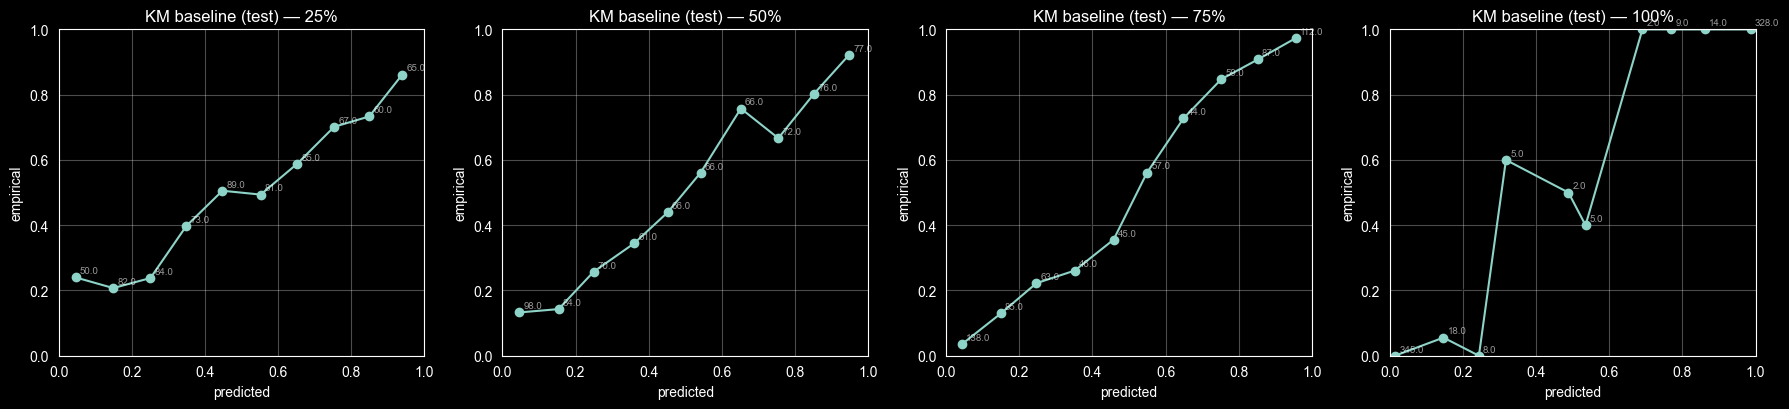

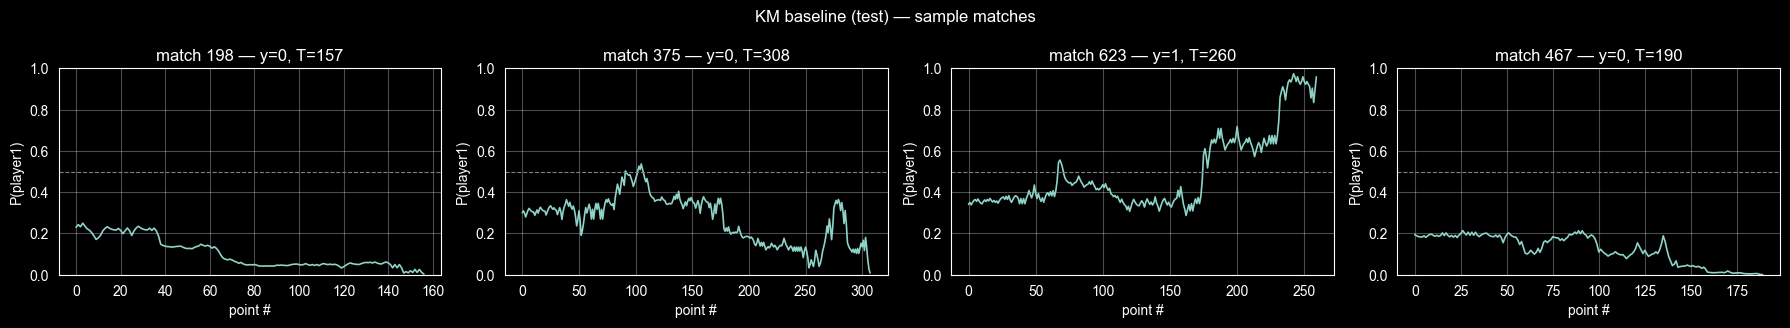


KM_RESULT saved.


In [11]:
import sys

sys.setrecursionlimit(5000)

KM_CACHE = CACHE_DIR / "km_probs.npz"

SLAM_START_DOY = {  # день года: ~начало турнира
    "ausopen": 17,
    "frenchopen": 145,
    "wimbledon": 178,
    "usopen": 240,
}


def _slam_start(year, slam):
    return pd.Timestamp(f"{int(year)}-01-01") + pd.Timedelta(days=SLAM_START_DOY[slam] - 1)


meta_full = meta_df.copy()
meta_full["slam_start"] = [_slam_start(y, s) for y, s in zip(meta_full["year"], meta_full["slam"])]
meta_priors = meta_with_priors.copy()
meta_priors["slam_start"] = [_slam_start(y, s) for y, s in zip(meta_priors["year"], meta_priors["slam"])]


def build_serve_stats(meta, points):
    p = points[["match_id", "PointServer", "PointWinner"]].dropna().copy()
    p["PointServer"] = p["PointServer"].astype(int)
    p["PointWinner"] = p["PointWinner"].astype(int)
    p1_pts = (p["PointServer"] == 1).groupby(p["match_id"]).sum()
    p2_pts = (p["PointServer"] == 2).groupby(p["match_id"]).sum()
    p1_won = ((p["PointServer"] == 1) & (p["PointWinner"] == 1)).groupby(p["match_id"]).sum()
    p2_won = ((p["PointServer"] == 2) & (p["PointWinner"] == 2)).groupby(p["match_id"]).sum()
    rows = []
    for _, m in meta.iterrows():
        mid = m["match_id"]
        rows.append({"match_id": mid, "date": m["slam_start"], "surface": m["surface"],
                     "player": m["player1"], "serve_pts": int(p1_pts.get(mid, 0)),
                     "serve_pts_won": int(p1_won.get(mid, 0))})
        rows.append({"match_id": mid, "date": m["slam_start"], "surface": m["surface"],
                     "player": m["player2"], "serve_pts": int(p2_pts.get(mid, 0)),
                     "serve_pts_won": int(p2_won.get(mid, 0))})
    return pd.DataFrame(rows)


serve_stats = build_serve_stats(meta_full, points_df)
print(f"serve_stats: {len(serve_stats):,} rows ({serve_stats['match_id'].nunique():,} matches), "
      f"{serve_stats['player'].nunique():,} unique players")
print(f"  total serve pts: {serve_stats['serve_pts'].sum():,}, "
      f"won: {serve_stats['serve_pts_won'].sum():,} "
      f"(overall p_serve = {serve_stats['serve_pts_won'].sum() / serve_stats['serve_pts'].sum():.3f})")

# Индекс по игроку
serve_history = {p: g.sort_values("date").reset_index(drop=True)
                 for p, g in serve_stats.groupby("player")}


TOUR_AVG_PSERVE_MEN = 0.62
LOOKBACK = pd.Timedelta(days=365)
MIN_SERVE_PTS = 200


def compute_p_serve(player, date, surface):
    h = serve_history.get(player)
    if h is None:
        return TOUR_AVG_PSERVE_MEN, "no_history", 0
    sel = (h["date"] >= date - LOOKBACK) & (h["date"] < date)
    h_w = h[sel]
    if len(h_w) == 0:
        return TOUR_AVG_PSERVE_MEN, "no_window", 0
    h_surf = h_w[h_w["surface"] == surface]
    surf_pts = int(h_surf["serve_pts"].sum())
    if surf_pts >= MIN_SERVE_PTS:
        return float(h_surf["serve_pts_won"].sum() / surf_pts), "surface", surf_pts
    total = int(h_w["serve_pts"].sum())
    if total >= MIN_SERVE_PTS:
        return float(h_w["serve_pts_won"].sum() / total), "all_surface", total
    return TOUR_AVG_PSERVE_MEN, "fallback_insufficient", total


def build_match_predictor(p1_serve, p2_serve, best_of=5, tb_cap=30):
    need = (best_of + 1) // 2

    def make_G(p):
        cache = {}

        def G(a, b):
            if (a, b) in cache: return cache[(a, b)]
            if a >= 4 and a - b >= 2:
                r = 1.0
            elif b >= 4 and b - a >= 2:
                r = 0.0
            elif a >= 3 and b >= 3:
                denom = p * p + (1 - p) * (1 - p)
                d = (p * p) / denom if denom > 1e-12 else 0.5
                if a == b:
                    r = d
                elif a > b:
                    r = p + (1 - p) * d
                else:
                    r = p * d
            else:
                r = p * G(a + 1, b) + (1 - p) * G(a, b + 1)
            cache[(a, b)] = r
            return r

        return G

    G1 = make_G(p1_serve)
    G2 = make_G(p2_serve)

    def p1_wins_game(a, b, srv_p1):
        return G1(a, b) if srv_p1 else 1.0 - G2(b, a)

    def tb_server_p1(n, fsv_p1):
        return fsv_p1 if (n == 0 or ((n - 1) // 2) % 2 == 0) else (not fsv_p1)

    tb_cache = {}

    def TB(a, b, fsv_p1):
        k = (a, b, fsv_p1)
        if k in tb_cache: return tb_cache[k]
        if a >= 7 and a - b >= 2:
            r = 1.0
        elif b >= 7 and b - a >= 2:
            r = 0.0
        elif a >= tb_cap or b >= tb_cap:
            r = 0.5
        else:
            srv_p1 = tb_server_p1(a + b, fsv_p1)
            p_p1_pt = p1_serve if srv_p1 else (1 - p2_serve)
            r = p_p1_pt * TB(a + 1, b, fsv_p1) + (1 - p_p1_pt) * TB(a, b + 1, fsv_p1)
        tb_cache[k] = r
        return r

    p1g_p1srv = p1_wins_game(0, 0, True)
    p1g_p2srv = p1_wins_game(0, 0, False)

    set_cache = {}
    SET_CAP = 15

    def S(g1, g2, srv_p1):
        k = (g1, g2, srv_p1)
        if k in set_cache: return set_cache[k]
        if g1 == 6 and g2 == 6:
            r = TB(0, 0, srv_p1)
        elif g1 >= 6 and g1 - g2 >= 2:
            r = 1.0
        elif g2 >= 6 and g2 - g1 >= 2:
            r = 0.0
        elif g1 >= SET_CAP or g2 >= SET_CAP:
            r = 0.5
        else:
            p_p1_g = p1g_p1srv if srv_p1 else p1g_p2srv
            next_srv = not srv_p1
            r = p_p1_g * S(g1 + 1, g2, next_srv) + (1 - p_p1_g) * S(g1, g2 + 1, next_srv)
        set_cache[k] = r
        return r

    match_cache = {}

    def M(s1, s2, srv_p1):
        k = (s1, s2, srv_p1)
        if k in match_cache: return match_cache[k]
        if s1 >= need:
            r = 1.0
        elif s2 >= need:
            r = 0.0
        else:
            p_set = S(0, 0, srv_p1)
            next_srv = not srv_p1
            r = p_set * M(s1 + 1, s2, next_srv) + (1 - p_set) * M(s1, s2 + 1, next_srv)
        match_cache[k] = r
        return r

    def predict(s1, s2, g1, g2, a, b, in_tb, srv_p1):
        if s1 >= need: return 1.0
        if s2 >= need: return 0.0
        if in_tb:
            n = a + b
            fsv = srv_p1 if (n == 0 or ((n - 1) // 2) % 2 == 0) else (not srv_p1)
            p_p1_set = TB(a, b, fsv)
        else:
            pwg = p1_wins_game(a, b, srv_p1)
            next_srv = not srv_p1
            p_p1_set = pwg * S(g1 + 1, g2, next_srv) + (1 - pwg) * S(g1, g2 + 1, next_srv)
        next_set_srv = not srv_p1
        return p_p1_set * M(s1 + 1, s2, next_set_srv) + (1 - p_p1_set) * M(s1, s2 + 1, next_set_srv)

    return predict

COL_S1 = FEATURE_NAMES.index("p1_sets")
COL_S2 = FEATURE_NAMES.index("p2_sets")
COL_G1 = FEATURE_NAMES.index("p1_games")
COL_G2 = FEATURE_NAMES.index("p2_games")
COL_A = FEATURE_NAMES.index("p1_pts_in_game")
COL_B = FEATURE_NAMES.index("p2_pts_in_game")
COL_TB = FEATURE_NAMES.index("is_tiebreak")
COL_SV = FEATURE_NAMES.index("p1_serving")


def predict_match_km(match_id, T_max, predictor):
    f = feats_by_id[match_id]  # (T_i, F)
    T_i = f.shape[0]
    out = np.full(T_max, 0.5, dtype=np.float32)
    for t in range(T_i):
        s1 = int(round(f[t, COL_S1]));
        s2 = int(round(f[t, COL_S2]))
        g1 = int(round(f[t, COL_G1]));
        g2 = int(round(f[t, COL_G2]))
        a = int(round(f[t, COL_A]));
        b = int(round(f[t, COL_B]))
        in_tb = bool(round(f[t, COL_TB]))
        srv_p1 = bool(round(f[t, COL_SV]))
        out[t] = predictor(s1, s2, g1, g2, a, b, in_tb, srv_p1)
    return out


def km_run_split(split_name):
    sp = splits[split_name]
    match_ids = sp["match_ids"]
    T_max = sp["X"].shape[1]
    N = len(match_ids)
    probs = np.zeros((N, T_max), dtype=np.float32)
    p_serve_log = []

    meta_idx = meta_priors.set_index("match_id")

    t0 = time.time()
    for i, mid in enumerate(match_ids):
        m = meta_idx.loc[mid]
        p1, p2, surface, date = m["player1"], m["player2"], m["surface"], m["slam_start"]
        ps1, src1, n1 = compute_p_serve(p1, date, surface)
        ps2, src2, n2 = compute_p_serve(p2, date, surface)
        p_serve_log.append({"match_id": mid, "p1_serve": ps1, "p1_src": src1, "p1_n": n1,
                            "p2_serve": ps2, "p2_src": src2, "p2_n": n2})
        predictor = build_match_predictor(ps1, ps2, best_of=5)
        probs[i] = predict_match_km(mid, T_max, predictor)
    dt = time.time() - t0
    print(f"  {split_name}: {N} matches in {dt:.1f}s ({1000 * dt / N:.1f} ms/match)")
    return probs, pd.DataFrame(p_serve_log)


if KM_CACHE.exists():
    z = np.load(KM_CACHE, allow_pickle=False)
    km_probs = {s: z[f"{s}_probs"] for s in ("train", "val", "test")}
    print(f"loaded KM probs from cache")
else:
    print("computing KM probs (this is one-time)...")
    km_probs = {}
    p_serve_logs = {}
    for s in ("val", "test", "train"):
        km_probs[s], p_serve_logs[s] = km_run_split(s)
    save = {f"{s}_probs": v for s, v in km_probs.items()}
    np.savez_compressed(KM_CACHE, **save)
    print(f"saved KM probs to {KM_CACHE.name}")

    # Print fallback stats
    for s, log in p_serve_logs.items():
        n = len(log)
        n_fb_p1 = (log["p1_src"].str.startswith("fallback") | (log["p1_src"] == "no_history") | (log["p1_src"] == "no_window")).sum()
        n_fb_p2 = (log["p2_src"].str.startswith("fallback") | (log["p2_src"] == "no_history") | (log["p2_src"] == "no_window")).sum()
        n_surf = ((log["p1_src"] == "surface") & (log["p2_src"] == "surface")).sum()
        print(f"  {s}: fallback_p1={n_fb_p1}/{n} ({n_fb_p1 / n:.1%}), "
              f"fallback_p2={n_fb_p2}/{n} ({n_fb_p2 / n:.1%}), "
              f"both_surface={n_surf}/{n} ({n_surf / n:.1%})")

# --- (g) Evaluator ---
print("\n" + "=" * 80)
print("=== KM baseline — evaluator on TEST ===")
res_test = evaluate_probs(km_probs["test"], splits["test"])
print("\nPrefix metrics:")
print(res_test["prefix_metrics"].to_string(index=False))
print("\nSanity:")
for k, v in res_test["sanity"].items():
    print(f"  {k}: {v:.4f}")

print("\n" + "=" * 80)
print("=== KM baseline — evaluator on VAL ===")
res_val = evaluate_probs(km_probs["val"], splits["val"])
print("\nPrefix metrics:")
print(res_val["prefix_metrics"].to_string(index=False))

# Калибровочные кривые на test
fig_cal = plot_calibration(res_test["calibration"], title="KM baseline (test)")
plt.show()

# Кривые отдельных матчей
fig_curves = plot_match_curves(km_probs["test"], splits["test"]["y"],
                               splits["test"]["lengths"], n=4, seed=0,
                               title="KM baseline (test) — sample matches")
plt.show()

# Сохраняем результаты для финальной таблицы
KM_RESULT = {
    "name": "Klaassen-Magnus closed-form",
    "category": "non-DL baseline (in-play)",
    "config": {"p_serve_lookback_days": 365, "min_serve_pts": MIN_SERVE_PTS,
               "fallback": TOUR_AVG_PSERVE_MEN},
    "test_prefix_metrics": res_test["prefix_metrics"],
    "test_sanity": res_test["sanity"],
}
print("\nKM_RESULT saved.")


## 7. Эксперимент 1 MLP per-point (DL baseline без памяти)

В седьмом разделе сделал самую простую DL-модель — MLP без памяти. Три полносвязных слоя 27 > 128 > 64 > 1, ReLU, dropout, и всё.

Это DL baseline. На каждом розыгрыше модель видит только текущую точку + prior, никакой связи между точками. Если LSTM/Transformer потом не обойдут MLP
заметно значит память бесполезна, и сложные архитектуры не нужны. LSTM и Transformer должны бить MLP, иначе recurrence/attention не несут пользы.


=== MLP per-point (alpha=0.5) ===
params: 11,905
  ep  1: train=0.4026  val=0.3614  lr=1.0e-03
  ep  2: train=0.3268  val=0.3572  lr=1.0e-03
  ep  3: train=0.3238  val=0.3595  lr=1.0e-03
  ep  4: train=0.3199  val=0.3557  lr=1.0e-03
  ep  5: train=0.3179  val=0.3594  lr=1.0e-03
  ep  6: train=0.3171  val=0.3579  lr=1.0e-03
  ep  7: train=0.3151  val=0.3576  lr=5.0e-04
  ep  8: train=0.3123  val=0.3555  lr=5.0e-04
  ep  9: train=0.3108  val=0.3544  lr=5.0e-04
  ep 10: train=0.3111  val=0.3555  lr=5.0e-04
  ep 11: train=0.3106  val=0.3576  lr=5.0e-04
  ep 12: train=0.3102  val=0.3563  lr=2.5e-04
  ep 13: train=0.3086  val=0.3551  lr=2.5e-04
  ep 14: train=0.3084  val=0.3551  lr=2.5e-04
  early stop at ep 14

trained 14 epochs in 15.7s, best val_loss=0.3544

Test prefix metrics:
prefix  accuracy  log_loss    brier      auc
   25%  0.740489  0.534360 0.178093 0.816445
   50%  0.783967  0.450029 0.144402 0.875000
   75%  0.847826  0.307876 0.097608 0.943373
  100%  0.993207  0.090540 0.018

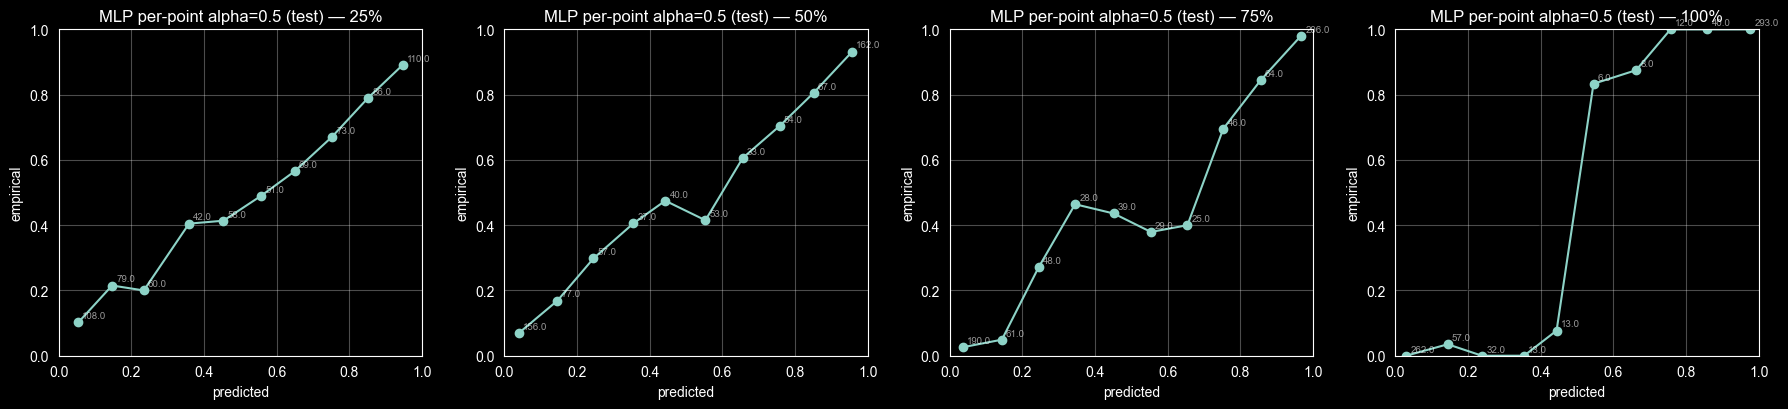

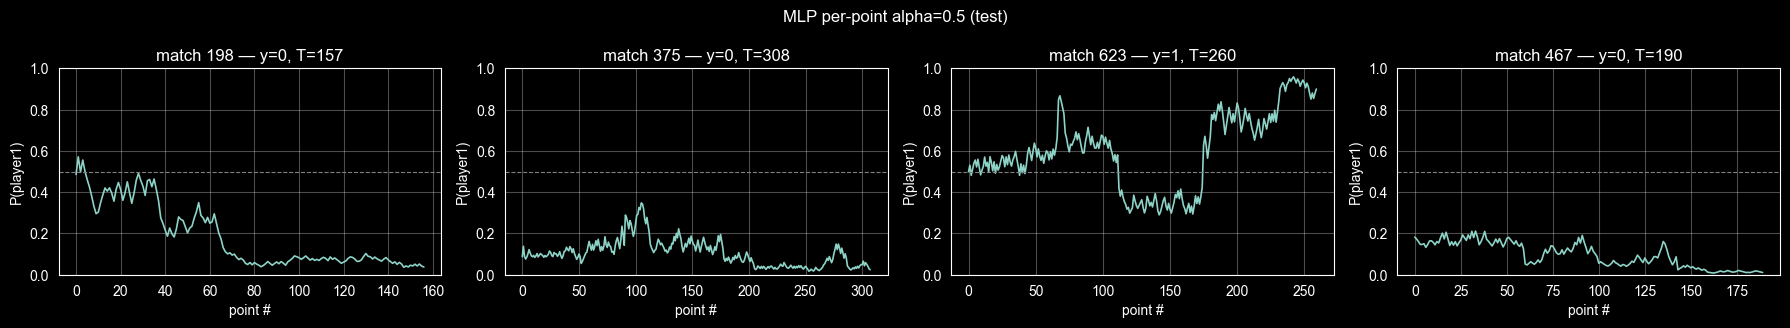


MLP_RESULTS saved.


In [12]:
"""Эксперимент 1: MLP per-point — DL baseline без памяти."""
import copy


class TennisDataset(Dataset):
    def __init__(self, split):
        self.X = torch.from_numpy(split["X"]).float()
        self.prior = torch.from_numpy(split["prior"]).float()
        self.mask = torch.from_numpy(split["mask"]).bool()
        self.y = torch.from_numpy(split["y"]).float()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.prior[i], self.mask[i], self.y[i]


def make_loader(split, batch_size=32, shuffle=False):
    return DataLoader(TennisDataset(split), batch_size=batch_size,
                      shuffle=shuffle, num_workers=0)


F_SEQ = splits["train"]["X"].shape[2]
F_PRIOR = splits["train"]["prior"].shape[1]


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_loop(model, splits, alpha=0.5, epochs=30, batch_size=32, lr=1e-3,
               weight_decay=0.0, patience=5, grad_clip=1.0, verbose=True):
    """Универсальный train loop для всех DL-экспериментов.

    Возвращает dict с history (per-epoch train/val loss, lr), best_val_loss, epochs, elapsed_sec.
    Лучший по val log_loss state восстанавливается в model перед возвратом.
    """
    model = model.to(DEVICE)
    train_loader = make_loader(splits["train"], batch_size, shuffle=True)
    val_loader = make_loader(splits["val"], batch_size, shuffle=False)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=2)

    history = []
    best_val = float("inf")
    best_state = None
    no_improve = 0
    last_ep = 0
    t0 = time.time()
    for ep in range(1, epochs + 1):
        last_ep = ep
        model.train()
        train_loss_sum = 0.0
        train_n = 0
        for xs, xp, m, y in train_loader:
            xs, xp, m, y = xs.to(DEVICE), xp.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
            T = m.shape[1]
            y_bt = y.unsqueeze(1).expand(-1, T)
            logits = model(xs, xp, m)
            loss = position_weighted_bce_loss(logits, y_bt, m, alpha=alpha)
            opt.zero_grad()
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            train_loss_sum += loss.item() * y.size(0)
            train_n += y.size(0)
        train_loss = train_loss_sum / max(train_n, 1)

        model.eval()
        val_loss_sum = 0.0
        val_n = 0
        with torch.no_grad():
            for xs, xp, m, y in val_loader:
                xs, xp, m, y = xs.to(DEVICE), xp.to(DEVICE), m.to(DEVICE), y.to(DEVICE)
                T = m.shape[1]
                y_bt = y.unsqueeze(1).expand(-1, T)
                logits = model(xs, xp, m)
                loss = position_weighted_bce_loss(logits, y_bt, m, alpha=alpha)
                val_loss_sum += loss.item() * y.size(0)
                val_n += y.size(0)
        val_loss = val_loss_sum / max(val_n, 1)

        sched.step(val_loss)
        cur_lr = opt.param_groups[0]["lr"]
        history.append({"epoch": ep, "train_loss": train_loss, "val_loss": val_loss, "lr": cur_lr})

        if verbose:
            print(f"  ep {ep:2d}: train={train_loss:.4f}  val={val_loss:.4f}  lr={cur_lr:.1e}")

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print(f"  early stop at ep {ep}")
                break

    elapsed = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)
    return {"history": pd.DataFrame(history), "best_val_loss": best_val,
            "epochs": last_ep, "elapsed_sec": elapsed}


def run_experiment(name, model_fn, alpha=0.5, **train_kwargs):
    """Один прогон эксперимента: build → train → evaluate → summary."""
    print(f"\n{'=' * 80}\n=== {name} (alpha={alpha}) ===")
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    model = model_fn()
    n_params = count_params(model)
    print(f"params: {n_params:,}")
    info = train_loop(model, splits, alpha=alpha, **train_kwargs)
    print(f"\ntrained {info['epochs']} epochs in {info['elapsed_sec']:.1f}s, "
          f"best val_loss={info['best_val_loss']:.4f}")
    res = evaluate_model(model, splits["test"], DEVICE)
    print("\nTest prefix metrics:")
    print(res["prefix_metrics"].to_string(index=False))
    print("\nSanity:")
    for k, v in res["sanity"].items():
        print(f"  {k}: {v:.4f}")
    return {"name": name, "alpha": alpha, "n_params": n_params,
            "epochs": info["epochs"], "elapsed_sec": info["elapsed_sec"],
            "best_val_loss": info["best_val_loss"],
            "test_prefix_metrics": res["prefix_metrics"],
            "test_sanity": res["sanity"],
            "test_calibration": res["calibration"],
            "history": info["history"], "probs": res["probs"]}


# --- MLP модель ---
class MLPPerPoint(nn.Module):
    def __init__(self, f_seq=F_SEQ, f_prior=F_PRIOR, hidden1=128, hidden2=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(f_seq + f_prior, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )

    def forward(self, xs, xp, m):
        # xs: (B, T, F_seq), xp: (B, F_prior), m: (B, T)
        T = xs.shape[1]
        xp_b = xp.unsqueeze(1).expand(-1, T, -1)
        z = torch.cat([xs, xp_b], dim=-1)
        return self.net(z).squeeze(-1)  # (B, T)


# --- Прогон alpha=0.5 ---
mlp_a05 = run_experiment("MLP per-point", lambda: MLPPerPoint(),
                         alpha=0.5, epochs=30, batch_size=32, lr=1e-3, patience=5)

fig_cal_mlp = plot_calibration(mlp_a05["test_calibration"],
                               title="MLP per-point alpha=0.5 (test)")
plt.show()

fig_curves_mlp = plot_match_curves(mlp_a05["probs"], splits["test"]["y"],
                                   splits["test"]["lengths"], n=4, seed=0,
                                   title="MLP per-point alpha=0.5 (test)")
plt.show()

MLP_RESULTS = {"alpha_0.5": mlp_a05}
print("\nMLP_RESULTS saved.")


## 8. Эксперимент 2 LSTM (DeepTennis-style)

В восьмом разделе сделал LSTM первая модель с настоящей памятью.

Архитектура: prior идёт через свою маленькую ветку Linear(10 > 32) > ReLU, получается prior_emb. Дальше этот эмбеддинг broadcast'ится по T и конкатенируется с
sequence-фичами на каждом шаге. На вход LSTM приходит (B, T, 49) 17 sequence + 32 prior. Один слой, hidden=50, dropout 0.3, классификатор Linear(50 > 1) поточечно.
Именно hidden=50 это прямой референс из DeepTennis. У них в работе тоже 50, и это сознательный выбор: state space тенниса
небольшой, 50-мерной памяти достаточно. Не стал брать «стандартные» 128 или 256, чтобы остаться сопоставимым с paper'ом.

Padding обрабатывается через mask в loss-функции LSTM прогоняется по всей длине T_max, но на padded позициях BCE не считается. Это упрощает код vs pack_padded_sequence
и почти не теряет в скорости на нашем размере батча.


=== LSTM-50 concat (DeepTennis honest) (alpha=0.5) ===
params: 20,603
  ep  1: train=0.4318  val=0.3776  lr=1.0e-03
  ep  2: train=0.3326  val=0.3596  lr=1.0e-03
  ep  3: train=0.3243  val=0.3570  lr=1.0e-03
  ep  4: train=0.3186  val=0.3582  lr=1.0e-03
  ep  5: train=0.3140  val=0.3600  lr=1.0e-03
  ep  6: train=0.3115  val=0.3577  lr=5.0e-04
  ep  7: train=0.3060  val=0.3589  lr=5.0e-04
  ep  8: train=0.3037  val=0.3614  lr=5.0e-04
  early stop at ep 8

trained 8 epochs in 8.6s, best val_loss=0.3570

Test prefix metrics:
prefix  accuracy  log_loss    brier      auc
   25%  0.751359  0.536661 0.177860 0.813697
   50%  0.797554  0.448645 0.143147 0.876093
   75%  0.857337  0.309307 0.097480 0.942893
  100%  0.978261  0.123905 0.027113 0.998574

Sanity:
  spearman_p_first_vs_elo_diff: 0.9455
  std_p_first: 0.0741
  std_p_last: 0.4152
  frac_p_first_in_0.4_0.6: 0.7962
  frac_p_last_in_0.4_0.6: 0.0421
  acc_at_50pct: 0.7976
  acc_at_50pct_vs_prematch_0.6714: 0.1262


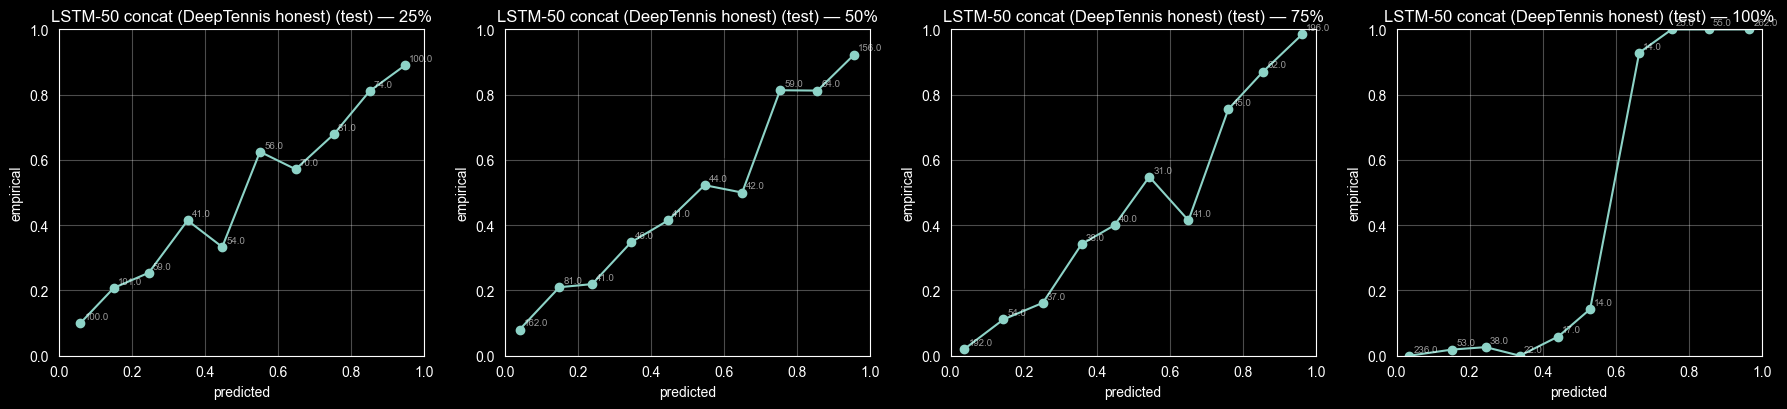

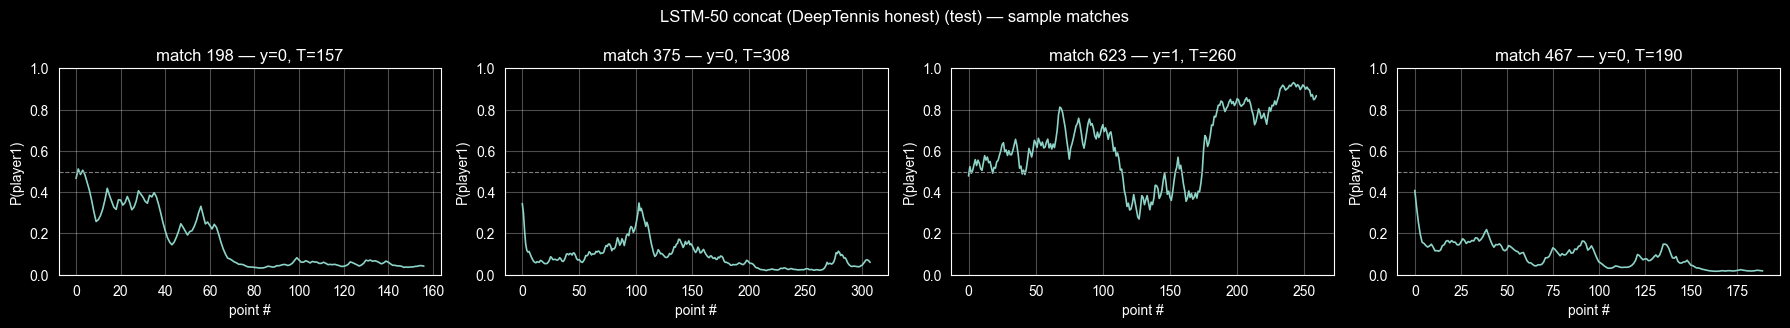


LSTM_RESULTS saved.


In [13]:
class LSTMModel(nn.Module):
    def __init__(self, f_seq=F_SEQ, f_prior=F_PRIOR, hidden=64, num_layers=1,
                 dropout=0.3, prior_emb=32, fusion="concat"):
        super().__init__()
        assert fusion in ("concat", "init")
        self.fusion = fusion
        self.hidden = hidden
        self.num_layers = num_layers

        self.prior_mlp = nn.Sequential(
            nn.Linear(f_prior, prior_emb),
            nn.ReLU(),
        )

        if fusion == "concat":
            self.lstm = nn.LSTM(f_seq + prior_emb, hidden, num_layers=num_layers,
                                batch_first=True,
                                dropout=dropout if num_layers > 1 else 0.0)
        else:
            self.lstm = nn.LSTM(f_seq, hidden, num_layers=num_layers,
                                batch_first=True,
                                dropout=dropout if num_layers > 1 else 0.0)
            self.h0_proj = nn.Linear(prior_emb, num_layers * hidden)
            self.c0_proj = nn.Linear(prior_emb, num_layers * hidden)

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, 1)

    def forward(self, xs, xp, m):
        B, T, _ = xs.shape
        prior_emb = self.prior_mlp(xp)
        if self.fusion == "concat":
            prior_b = prior_emb.unsqueeze(1).expand(-1, T, -1)
            x = torch.cat([xs, prior_b], dim=-1)
            out, _ = self.lstm(x)
        else:
            h0 = self.h0_proj(prior_emb).view(B, self.num_layers, self.hidden) \
                .transpose(0, 1).contiguous()
            c0 = self.c0_proj(prior_emb).view(B, self.num_layers, self.hidden) \
                .transpose(0, 1).contiguous()
            out, _ = self.lstm(xs, (h0, c0))
        out = self.dropout(out)
        return self.classifier(out).squeeze(-1)


LSTM_RESULTS = {}
lstm50_label = "LSTM-50 concat"
res = run_experiment(
    lstm50_label,
    lambda: LSTMModel(hidden=50, fusion="concat"),
    alpha=0.5, epochs=30, batch_size=32, lr=1e-3, patience=5,
)
LSTM_RESULTS[lstm50_label] = res

# Калибровка и кривые матчей
fig_cal_lstm = plot_calibration(res["test_calibration"],
                                title=f"{lstm50_label} (test)")
plt.show()
fig_curves_lstm = plot_match_curves(res["probs"], splits["test"]["y"],
                                    splits["test"]["lengths"], n=4, seed=0,
                                    title=f"{lstm50_label} (test) — sample matches")
plt.show()

print("\nLSTM_RESULTS saved.")


## 9. Эксперимент 3 GRU

GRU рекуррентная сеть с двумя гейтами (update + reset) вместо четырёх в LSTM, без cell state. Меньше параметров на тот же hidden, обычно сопоставимое качество на не слишком длинных последовательностях. Имеет смысл проверить, не достаточен ли GRU вместо LSTM.

**Архитектура.** Идентична LSTM (concat-fusion для priors), только `nn.LSTM` → `nn.GRU`.

**Прогоны.** `hidden=50` (для fair сравнения с лучшим LSTM-50) и `hidden=128` (план).


=== GRU-50 (alpha=0.5) ===
params: 15,553
  ep  1: train=0.4051  val=0.3786  lr=1.0e-03
  ep  2: train=0.3298  val=0.3631  lr=1.0e-03
  ep  3: train=0.3223  val=0.3577  lr=1.0e-03
  ep  4: train=0.3192  val=0.3572  lr=1.0e-03
  ep  5: train=0.3163  val=0.3577  lr=1.0e-03
  ep  6: train=0.3151  val=0.3543  lr=1.0e-03
  ep  7: train=0.3131  val=0.3555  lr=1.0e-03
  ep  8: train=0.3115  val=0.3544  lr=1.0e-03
  ep  9: train=0.3117  val=0.3576  lr=5.0e-04
  ep 10: train=0.3072  val=0.3533  lr=5.0e-04
  ep 11: train=0.3052  val=0.3548  lr=5.0e-04
  ep 12: train=0.3047  val=0.3553  lr=5.0e-04
  ep 13: train=0.3033  val=0.3571  lr=2.5e-04
  ep 14: train=0.3022  val=0.3566  lr=2.5e-04
  ep 15: train=0.3011  val=0.3558  lr=2.5e-04
  early stop at ep 15

trained 15 epochs in 15.8s, best val_loss=0.3533

Test prefix metrics:
prefix  accuracy  log_loss    brier      auc
   25%  0.748641  0.533575 0.176945 0.818366
   50%  0.792120  0.451391 0.144581 0.876330
   75%  0.849185  0.304904 0.096226 0.

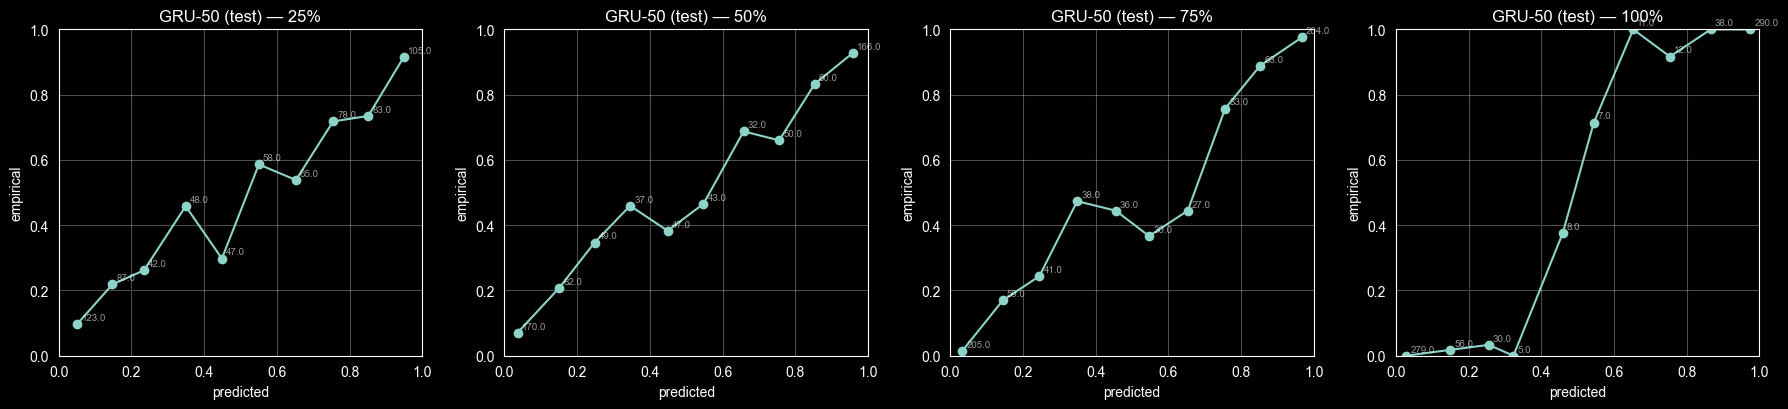

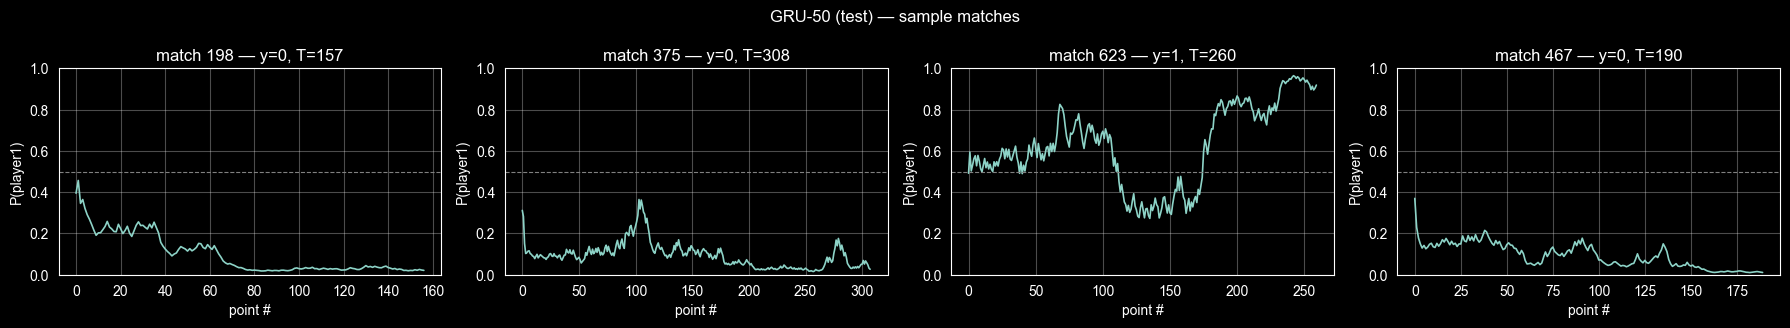


GRU_RESULTS saved.


In [14]:
class GRUModel(nn.Module):
    def __init__(self, f_seq=F_SEQ, f_prior=F_PRIOR, hidden=128, num_layers=1,
                 dropout=0.3, prior_emb=32):
        super().__init__()
        self.hidden = hidden
        self.num_layers = num_layers

        self.prior_mlp = nn.Sequential(
            nn.Linear(f_prior, prior_emb),
            nn.ReLU(),
        )
        self.gru = nn.GRU(f_seq + prior_emb, hidden, num_layers=num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, 1)

    def forward(self, xs, xp, m):
        T = xs.shape[1]
        prior_emb = self.prior_mlp(xp)
        prior_b = prior_emb.unsqueeze(1).expand(-1, T, -1)
        x = torch.cat([xs, prior_b], dim=-1)
        out, _ = self.gru(x)
        out = self.dropout(out)
        return self.classifier(out).squeeze(-1)


GRU_RESULTS = {}
gru_label = "GRU-50"
res = run_experiment(
    gru_label,
    lambda: GRUModel(hidden=50),
    alpha=0.5, epochs=30, batch_size=32, lr=1e-3, patience=5,
)
GRU_RESULTS[gru_label] = res

# Калибровка и кривые
fig_cal_gru = plot_calibration(res["test_calibration"],
                               title=f"{gru_label} (test)")
plt.show()
fig_curves_gru = plot_match_curves(res["probs"], splits["test"]["y"],
                                   splits["test"]["lengths"], n=4, seed=0,
                                   title=f"{gru_label} (test) — sample matches")
plt.show()

print("\nGRU_RESULTS saved.")

## 10. Эксперимент 4 Transformer encoder

В десятом разделе чистый Transformer-encoder по работе ATennision. Self-attention видит весь префикс сразу.
Sequence-фичи проектирую в d_model=128, prior идёт через отдельный MLP и подаётся первым токеном последовательности attention сам решает, насколько его использовать.

Маски causal чтобы не было лика. key_padding_mask не передаю, потому что padding всегда в конце, и causal маска уже отрезает невалидные позиции.

Гиперпараметры: lr=5e-4 (Transformer чувствительнее), batch_size=16 (квадратичная attention ест память). 416 897 параметров в 20 раз больше LSTM-50.


=== Transformer-2L (ATennision) (alpha=0.5) ===
params: 416,897


D:\Projects\TennisPredictor\venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  ep  1: train=0.3644  val=0.3676  lr=5.0e-04
  ep  2: train=0.3300  val=0.3664  lr=5.0e-04
  ep  3: train=0.3228  val=0.3710  lr=5.0e-04
  ep  4: train=0.3194  val=0.3678  lr=5.0e-04
  ep  5: train=0.3155  val=0.3603  lr=5.0e-04
  ep  6: train=0.3131  val=0.3580  lr=5.0e-04
  ep  7: train=0.3109  val=0.3558  lr=5.0e-04
  ep  8: train=0.3071  val=0.3544  lr=5.0e-04
  ep  9: train=0.3072  val=0.3621  lr=5.0e-04
  ep 10: train=0.3001  val=0.3684  lr=5.0e-04
  ep 11: train=0.2979  val=0.3791  lr=2.5e-04
  ep 12: train=0.2850  val=0.3635  lr=2.5e-04
  ep 13: train=0.2785  val=0.3787  lr=2.5e-04
  early stop at ep 13

trained 13 epochs in 59.8s, best val_loss=0.3544

Test prefix metrics:
prefix  accuracy  log_loss    brier      auc
   25%  0.730978  0.524008 0.175614 0.822976
   50%  0.793478  0.443728 0.142728 0.875628
   75%  0.855978  0.313557 0.098413 0.940462
  100%  0.987772  0.099943 0.019927 0.998914

Sanity:
  spearman_p_first_vs_elo_diff: 0.9112
  std_p_first: 0.2864
  std_p_last:

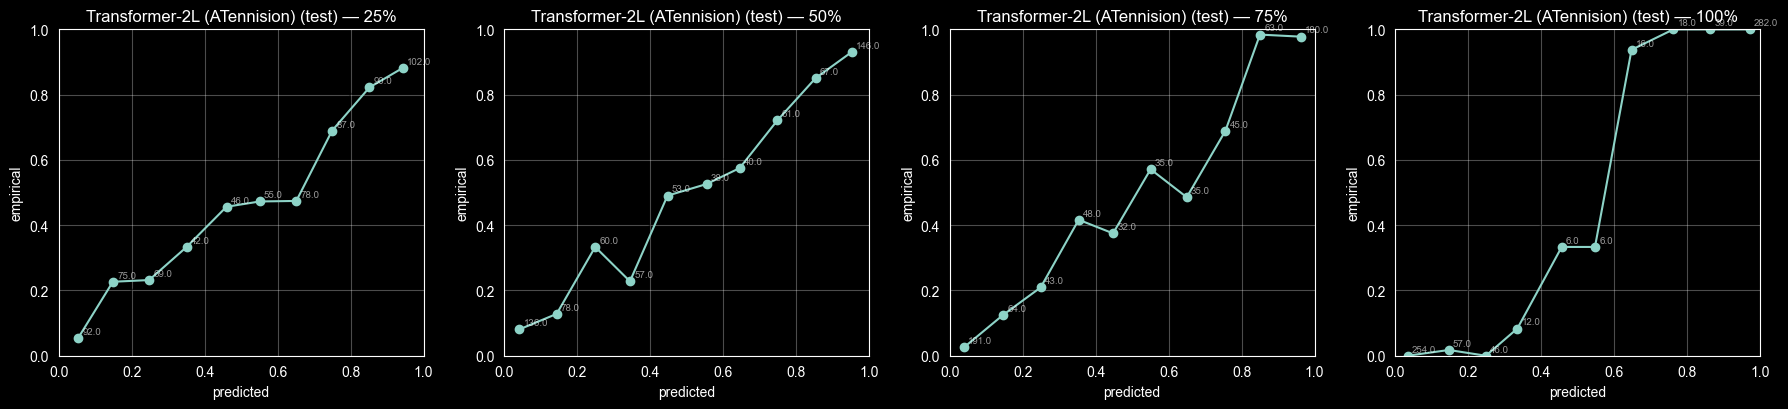

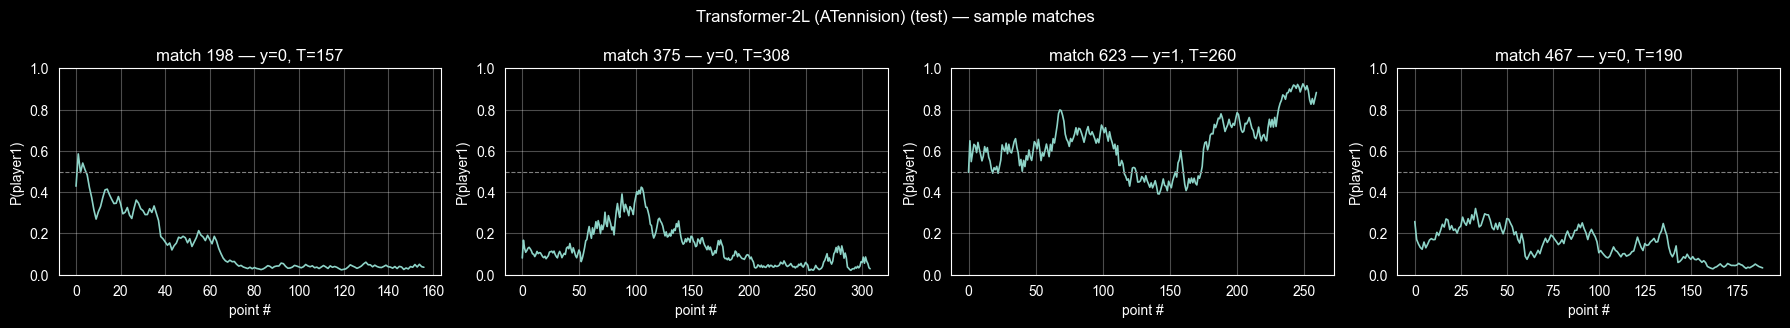


TRANSFORMER_RESULTS saved.


In [15]:
import math


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=600):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerEncoderATennision(nn.Module):
    def __init__(self, f_seq=F_SEQ, f_prior=F_PRIOR, d_model=128,
                 nhead=4, num_layers=2, ff_dim=512, dropout=0.2, max_len=600):
        super().__init__()
        self.d_model = d_model
        self.input_proj = nn.Linear(f_seq, d_model)
        self.prior_proj = nn.Sequential(
            nn.Linear(f_prior, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
        )

        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len=max_len + 2)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Linear(d_model, 1)

    def forward(self, xs, xp, m):
        B, T, _ = xs.shape
        x = self.input_proj(xs)
        prior_tok = self.prior_proj(xp).unsqueeze(1)
        z = torch.cat([prior_tok, x], dim=1)
        z = self.pos_enc(z)
        Tp = T + 1
        causal = torch.triu(torch.ones(Tp, Tp, device=z.device, dtype=torch.bool),
                            diagonal=1)
        out = self.encoder(z, mask=causal)
        out_seq = out[:, 1:, :]
        return self.classifier(out_seq).squeeze(-1)


TRANSFORMER_RESULTS = {}
tr_label = "Transformer-2L (ATennision)"
res = run_experiment(
    tr_label,
    lambda: TransformerEncoderATennision(
        d_model=128, nhead=4, num_layers=2, ff_dim=512, dropout=0.2,
    ),
    alpha=0.5, epochs=25, batch_size=16, lr=5e-4, patience=5,
)
TRANSFORMER_RESULTS[tr_label] = res

fig_cal_tr = plot_calibration(res["test_calibration"],
                              title=f"{tr_label} (test)")
plt.show()
fig_curves_tr = plot_match_curves(res["probs"], splits["test"]["y"],
                                  splits["test"]["lengths"], n=4, seed=0,
                                  title=f"{tr_label} (test) — sample matches")
plt.show()

print("\nTRANSFORMER_RESULTS saved.")


## 11. Эксперимент 5 Transformer + Momentum

Transformer + Momentum по работе Yu & Gao. К Transformer-2L из 10-го раздела добавил отдельную momentum-ветку с 5 явными
pressure-фичами: break_point, set_point для каждого игрока, match_point для каждого. Все бинарные, считаются векторизованно из raw state никаких новых данных.

Архитектура двухветочная: sequence-ветка та же, что у Transformer-2L. Momentum-ветка маленький MLP 5 → 32 → 32 per-step. На выходе конкат обоих эмбеддингов перед
классификатором: Linear(160 > 1). Идея дать pressure-моментам отдельный явный канал, а не ждать, что Transformer сам их выведет через attention.
418k параметров, почти столько же, сколько у vanilla Transformer.

Pressure feature rates on valid train points:
  break_pt: 8.6184%
  p1_set_pt: 1.4623%
  p2_set_pt: 1.4746%
  p1_match_pt: 0.3842%
  p2_match_pt: 0.3786%

=== Transformer + Momentum (Yu & Gao) (alpha=0.5) ===


D:\Projects\TennisPredictor\venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


params: 418,177
  ep  1: train=0.3659  val=0.3729  lr=5.0e-04
  ep  2: train=0.3303  val=0.3706  lr=5.0e-04
  ep  3: train=0.3249  val=0.3565  lr=5.0e-04
  ep  4: train=0.3208  val=0.3713  lr=5.0e-04
  ep  5: train=0.3149  val=0.3882  lr=5.0e-04
  ep  6: train=0.3135  val=0.3595  lr=2.5e-04
  ep  7: train=0.3028  val=0.3594  lr=2.5e-04
  ep  8: train=0.3009  val=0.3538  lr=2.5e-04
  ep  9: train=0.2993  val=0.3519  lr=2.5e-04
  ep 10: train=0.2963  val=0.3604  lr=2.5e-04
  ep 11: train=0.2911  val=0.3722  lr=2.5e-04
  ep 12: train=0.2895  val=0.3624  lr=1.3e-04
  ep 13: train=0.2788  val=0.3720  lr=1.3e-04
  ep 14: train=0.2738  val=0.3701  lr=1.3e-04
  early stop at ep 14

trained 14 epochs in 68.6s, best val_loss=0.3519

Test prefix metrics:
prefix  accuracy  log_loss    brier      auc
   25%  0.736413  0.535227 0.178924 0.814827
   50%  0.789402  0.472892 0.150874 0.863896
   75%  0.850543  0.318250 0.100031 0.939938
  100%  0.994565  0.045062 0.007808 0.999697

Sanity:
  spearman_p

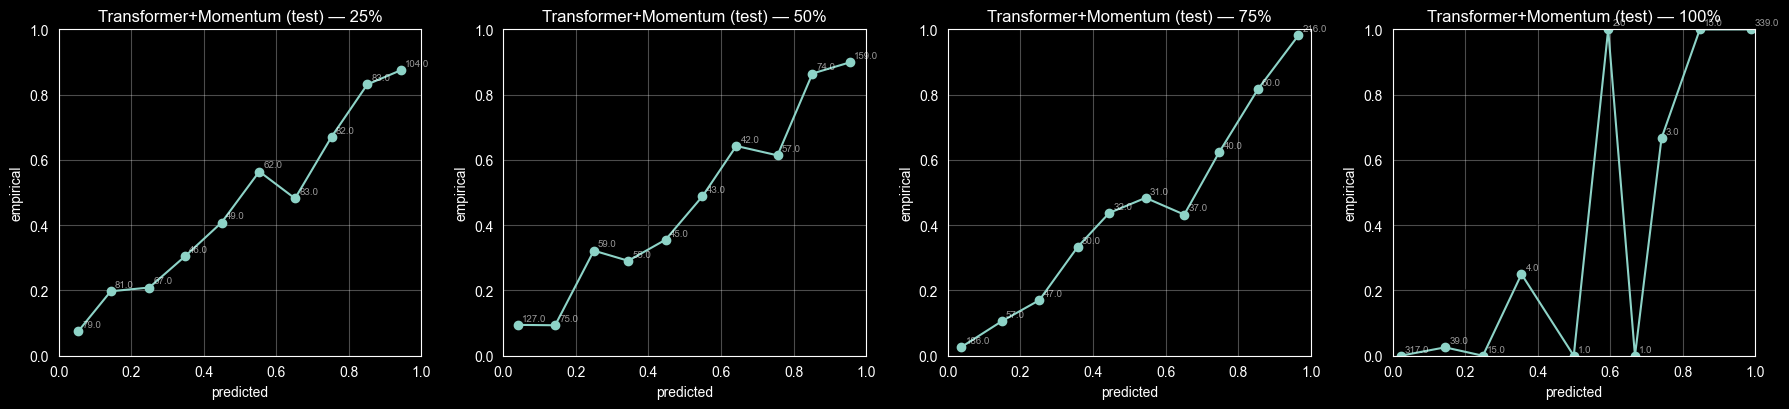

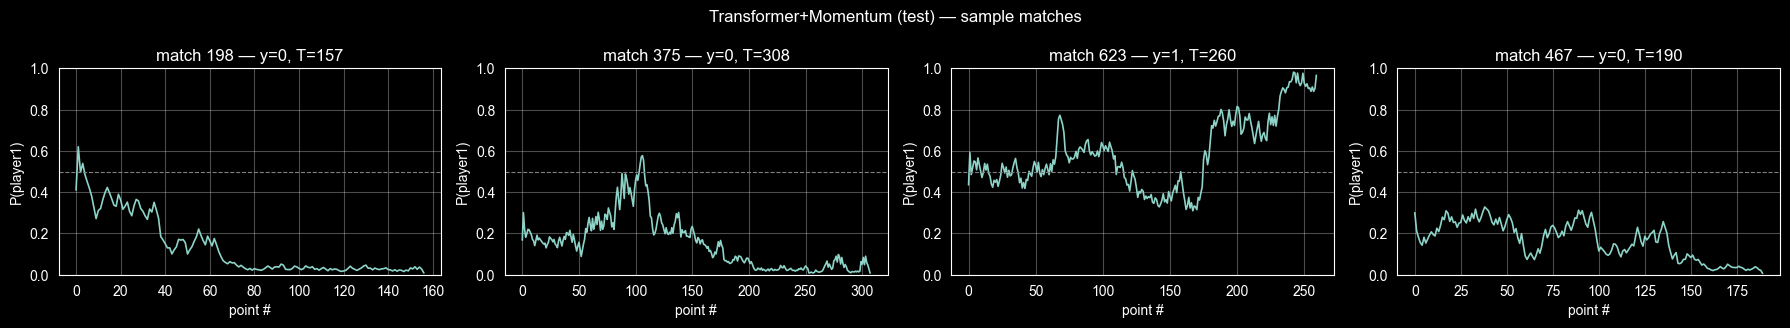


=== Transformer + Momentum vs reference (test) ===
                        model  params  epochs  time_s  best_val  acc@25%  acc@50%  acc@75%  acc@100%  auc@50%
Transformer+Momentum (Yu&Gao)  418177      14    68.6    0.3519   0.7364   0.7894   0.8505    0.9946   0.8639
  Transformer-2L (ATennision)  416897      13    59.8    0.3544   0.7310   0.7935   0.8560    0.9878   0.8756
                      LSTM-50   20603       8     8.6    0.3570   0.7514   0.7976   0.8573    0.9783   0.8761
                       GRU-50   15553      15    15.8    0.3533   0.7486   0.7921   0.8492    0.9891   0.8763

YG_RESULT saved.


In [16]:
def compute_pressure_features_vec(feats_raw, best_of=5):

    n = feats_raw.shape[0]
    if n == 0:
        return np.zeros((0, 5), dtype=np.float32)
    need_sets = (best_of + 1) // 2  # 3 для best_of=5

    s1 = feats_raw[:, COL_S1].astype(np.int32)
    s2 = feats_raw[:, COL_S2].astype(np.int32)
    g1 = feats_raw[:, COL_G1].astype(np.int32)
    g2 = feats_raw[:, COL_G2].astype(np.int32)
    a = feats_raw[:, COL_A].astype(np.int32)
    b = feats_raw[:, COL_B].astype(np.int32)
    in_tb = feats_raw[:, COL_TB].astype(bool)
    srv_p1 = feats_raw[:, COL_SV].astype(bool)

    pt_thresh = np.where(in_tb, 7, 4)


    p1_wins_game = ((a + 1) >= pt_thresh) & (((a + 1) - b) >= 2)
    p2_wins_game = ((b + 1) >= pt_thresh) & (((b + 1) - a) >= 2)


    break_pt = np.where(srv_p1, p2_wins_game, p1_wins_game)


    ng1 = g1 + 1
    ng2 = g2 + 1
    p1_set_pt_tb = p1_wins_game & in_tb
    p2_set_pt_tb = p2_wins_game & in_tb
    p1_set_pt_reg = p1_wins_game & (~in_tb) & (ng1 >= 6) & ((ng1 - g2) >= 2)
    p2_set_pt_reg = p2_wins_game & (~in_tb) & (ng2 >= 6) & ((ng2 - g1) >= 2)
    p1_set_pt = p1_set_pt_tb | p1_set_pt_reg
    p2_set_pt = p2_set_pt_tb | p2_set_pt_reg

    # Match point: выигрыш сета этим очком даёт s'+ = s+1, и s'+ >= need_sets
    p1_match_pt = p1_set_pt & ((s1 + 1) >= need_sets)
    p2_match_pt = p2_set_pt & ((s2 + 1) >= need_sets)

    return np.column_stack([
        break_pt.astype(np.float32),
        p1_set_pt.astype(np.float32),
        p2_set_pt.astype(np.float32),
        p1_match_pt.astype(np.float32),
        p2_match_pt.astype(np.float32),
    ])


PRESSURE_NAMES = ["break_pt", "p1_set_pt", "p2_set_pt", "p1_match_pt", "p2_match_pt"]
F_MOMENTUM = len(PRESSURE_NAMES)

splits_aug = {}
for s in ("train", "val", "test"):
    sp = splits[s]
    N, T_max, _ = sp["X"].shape
    pressure_X = np.zeros((N, T_max, F_MOMENTUM), dtype=np.float32)
    for i, mid in enumerate(sp["match_ids"]):
        f_raw = feats_by_id[mid]
        T_i = min(f_raw.shape[0], T_max)
        pressure_X[i, :T_i] = compute_pressure_features_vec(f_raw[:T_i])
    X_aug = np.concatenate([sp["X"], pressure_X], axis=-1).astype(np.float32)
    splits_aug[s] = {**sp, "X": X_aug}

mom_train = splits_aug["train"]["X"][..., F_SEQ:].reshape(-1, F_MOMENTUM)
mom_mask = splits_aug["train"]["mask"].reshape(-1)
mom_valid = mom_train[mom_mask]
print("Pressure feature rates on valid train points:")
for name, rate in zip(PRESSURE_NAMES, mom_valid.mean(axis=0)):
    print(f"  {name}: {rate:.4%}")


class TransformerWithMomentum(nn.Module):
    def __init__(self, f_seq=F_SEQ, f_momentum=F_MOMENTUM, f_prior=F_PRIOR,
                 d_model=128, nhead=4, num_layers=2, ff_dim=512,
                 momentum_dim=32, dropout=0.2, max_len=600):
        super().__init__()
        self.f_seq = f_seq
        self.f_momentum = f_momentum

        self.input_proj = nn.Linear(f_seq, d_model)
        self.prior_proj = nn.Sequential(
            nn.Linear(f_prior, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
        )
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len=max_len + 2)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.momentum_mlp = nn.Sequential(
            nn.Linear(f_momentum, momentum_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(momentum_dim, momentum_dim),
            nn.ReLU(),
        )
        self.classifier = nn.Linear(d_model + momentum_dim, 1)

    def forward(self, xs_aug, xp, m):
        # xs_aug: (B, T, F_seq + F_momentum)
        xs = xs_aug[..., :self.f_seq]
        momentum = xs_aug[..., self.f_seq:self.f_seq + self.f_momentum]

        B, T, _ = xs.shape
        x = self.input_proj(xs)
        prior_tok = self.prior_proj(xp).unsqueeze(1)
        z = torch.cat([prior_tok, x], dim=1)
        z = self.pos_enc(z)
        Tp = T + 1
        causal = torch.triu(torch.ones(Tp, Tp, device=z.device, dtype=torch.bool),
                            diagonal=1)
        out = self.encoder(z, mask=causal)
        seq_emb = out[:, 1:, :]  # (B, T, d_model)

        mom_emb = self.momentum_mlp(momentum)  # (B, T, momentum_dim)
        fused = torch.cat([seq_emb, mom_emb], dim=-1)
        return self.classifier(fused).squeeze(-1)  # (B, T)


print(f"\n{'=' * 80}\n=== Transformer + Momentum (Yu & Gao) (alpha=0.5) ===")
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

model_yg = TransformerWithMomentum(
    d_model=128, nhead=4, num_layers=2, ff_dim=512, dropout=0.2,
)
n_params_yg = count_params(model_yg)
print(f"params: {n_params_yg:,}")

info_yg = train_loop(model_yg, splits_aug, alpha=0.5, epochs=25,
                     batch_size=16, lr=5e-4, patience=5)
print(f"\ntrained {info_yg['epochs']} epochs in {info_yg['elapsed_sec']:.1f}s, "
      f"best val_loss={info_yg['best_val_loss']:.4f}")

res_yg = evaluate_model(model_yg, splits_aug["test"], DEVICE)
print("\nTest prefix metrics:")
print(res_yg["prefix_metrics"].to_string(index=False))
print("\nSanity:")
for k, v in res_yg["sanity"].items():
    print(f"  {k}: {v:.4f}")

YG_RESULT = {
    "name": "Transformer + Momentum (Yu & Gao)",
    "alpha": 0.5,
    "n_params": n_params_yg,
    "epochs": info_yg["epochs"],
    "elapsed_sec": info_yg["elapsed_sec"],
    "best_val_loss": info_yg["best_val_loss"],
    "test_prefix_metrics": res_yg["prefix_metrics"],
    "test_sanity": res_yg["sanity"],
    "test_calibration": res_yg["calibration"],
    "history": info_yg["history"],
    "probs": res_yg["probs"],
}

fig_cal_yg = plot_calibration(res_yg["calibration"],
                              title="Transformer+Momentum (test)")
plt.show()
fig_curves_yg = plot_match_curves(res_yg["probs"], splits_aug["test"]["y"],
                                  splits_aug["test"]["lengths"], n=4, seed=0,
                                  title="Transformer+Momentum (test) — sample matches")
plt.show()

print("\n" + "=" * 80)
print("=== Transformer + Momentum vs reference (test) ===")


def _row(name, r):
    return {
        "model": name,
        "params": r["n_params"],
        "epochs": r["epochs"],
        "time_s": round(r["elapsed_sec"], 1),
        "best_val": round(r["best_val_loss"], 4),
        "acc@25%": round(r["test_prefix_metrics"].iloc[0]["accuracy"], 4),
        "acc@50%": round(r["test_prefix_metrics"].iloc[1]["accuracy"], 4),
        "acc@75%": round(r["test_prefix_metrics"].iloc[2]["accuracy"], 4),
        "acc@100%": round(r["test_prefix_metrics"].iloc[3]["accuracy"], 4),
        "auc@50%": round(r["test_prefix_metrics"].iloc[1]["auc"], 4),
    }


rows = [
    _row("Transformer+Momentum (Yu&Gao)", YG_RESULT),
    _row("Transformer-2L (ATennision)", TRANSFORMER_RESULTS["Transformer-2L (ATennision)"]),
    _row("LSTM-50", LSTM_RESULTS["LSTM-50 concat (DeepTennis honest)"]),
    _row("GRU-50", GRU_RESULTS["GRU-50"]),
]
yg_compare = pd.DataFrame(rows)
print(yg_compare.to_string(index=False))

print("\nYG_RESULT saved.")


## 12. ML-baseline на in-play фичах GradientBoosting

Сравненим DL и ML на in-play, нужен ML-baseline на ТЕХ ЖЕ per-step фичах, что и DL-модели. Klaassen-Magnus использует только `p_serve`; GradientBoosting видит весь набор (state + cumulative + momentum + ELO/ATP_RANK priors).

**Что делаем.**
- Каждая точка матча отдельная строка таблицы (`X_seq[t]` ⊕ `prior` broadcasted).
- Таргет победитель матча (один и тот же для всех точек одного матча).
- `HistGradientBoostingClassifier` (sklearn) быстрый аналог LightGBM, легко берёт ~5M точек.
- Метрики считаем теми же `prefix_metrics` (25/50/75/100%), что и для DL.


In [17]:
import time
from sklearn.ensemble import HistGradientBoostingClassifier


def _flatten_split(split, prior_dim_to_use=None):
    X = split["X"]
    prior = split["prior"]
    mask = split["mask"]
    y = split["y"]
    N, T_max, F_seq = X.shape
    F_prior = prior.shape[1] if prior_dim_to_use is None else prior_dim_to_use

    prior_b = np.broadcast_to(prior[:, None, :F_prior], (N, T_max, F_prior))
    full = np.concatenate([X, prior_b], axis=-1)

    flat_full = full.reshape(N * T_max, F_seq + F_prior)
    flat_mask = mask.reshape(N * T_max)
    match_idx = np.repeat(np.arange(N), T_max)
    step_idx = np.tile(np.arange(T_max), N)
    flat_y = np.repeat(y, T_max)

    keep = flat_mask.astype(bool)
    return (flat_full[keep], flat_y[keep],
            match_idx[keep], step_idx[keep])


def _predict_probs_grid(clf, split, prior_dim_to_use=None):

    X = split["X"]
    prior = split["prior"]
    N, T_max, F_seq = X.shape
    F_prior = prior.shape[1] if prior_dim_to_use is None else prior_dim_to_use
    prior_b = np.broadcast_to(prior[:, None, :F_prior], (N, T_max, F_prior))
    full = np.concatenate([X, prior_b], axis=-1).reshape(N * T_max, -1)
    p_flat = clf.predict_proba(full)[:, 1]
    return p_flat.reshape(N, T_max).astype(np.float32)


F_PRIOR_BASE_GB = splits["train"]["prior"].shape[1]

print(f"=== GradientBoosting on per-step features ===")
print(f"F_seq = {splits['train']['X'].shape[2]}, F_prior = {F_PRIOR_BASE_GB}, "
      f"total features = {splits['train']['X'].shape[2] + F_PRIOR_BASE_GB}")

t0 = time.time()
flat_X_tr, flat_y_tr, _, _ = _flatten_split(splits["train"])
print(f"train: {flat_X_tr.shape[0]:,} points, {flat_X_tr.shape[1]} features "
      f"(flattened in {time.time() - t0:.1f}s)")


clf_gb = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=6,
    learning_rate=0.05,
    l2_regularization=1.0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=SEED,
)

t0 = time.time()
clf_gb.fit(flat_X_tr, flat_y_tr)
gb_fit_time = time.time() - t0
print(f"fit: {clf_gb.n_iter_} iters in {gb_fit_time:.1f}s")

t0 = time.time()
gb_val_probs = _predict_probs_grid(clf_gb, splits["val"])
gb_test_probs = _predict_probs_grid(clf_gb, splits["test"])
print(f"predict val+test in {time.time() - t0:.1f}s")

gb_val_eval = evaluate_probs(gb_val_probs, splits["val"])
gb_test_eval = evaluate_probs(gb_test_probs, splits["test"])


n_trees = clf_gb.n_iter_

try:
    gb_n_params = sum(int(t[0].nodes.shape[0]) for t in clf_gb._predictors)
except Exception:
    gb_n_params = int(n_trees)  # fallback: считаем число деревьев

print(f"\nval prefix metrics:")
print(gb_val_eval["prefix_metrics"].to_string(index=False))
print(f"\ntest prefix metrics:")
print(gb_test_eval["prefix_metrics"].to_string(index=False))
print(f"\ntest sanity:")
for k, v in gb_test_eval["sanity"].items():
    print(f"  {k}: {v:.4f}")

val_mask = splits["val"]["mask"].astype(bool)
val_y_b = np.broadcast_to(splits["val"]["y"][:, None],
                          splits["val"]["mask"].shape)
val_p = np.clip(gb_val_probs, 1e-7, 1 - 1e-7)
gb_val_loss = float(-(val_y_b * np.log(val_p) +
                      (1 - val_y_b) * np.log(1 - val_p))[val_mask].mean())
print(f"\nval_loss (unweighted BCE on masked points) = {gb_val_loss:.4f}")

GB_RESULT = {
    "name": "GradientBoosting (HistGB) per-point",
    "n_params": int(gb_n_params),
    "n_trees": int(n_trees),
    "max_depth": 6,
    "epochs": int(n_trees),
    "elapsed_sec": float(gb_fit_time),
    "best_val_loss": gb_val_loss,
    "test_prefix_metrics": gb_test_eval["prefix_metrics"],
    "test_sanity": gb_test_eval["sanity"],
    "test_calibration": gb_test_eval["calibration"],
    "val_prefix_metrics": gb_val_eval["prefix_metrics"],
    "probs": gb_test_probs,
}

print("\nGB_RESULT saved.")

=== GradientBoosting on per-step features ===
F_seq = 17, F_prior = 10, total features = 27
train: 872,190 points, 27 features (flattened in 0.2s)
fit: 300 iters in 25.0s
predict val+test in 5.9s

val prefix metrics:
prefix  accuracy  log_loss    brier      auc
   25%  0.706967  0.552200 0.186454 0.795292
   50%  0.793033  0.463762 0.150566 0.862643
   75%  0.854508  0.349765 0.109134 0.923696
  100%  0.967213  0.133518 0.031629 0.996766

test prefix metrics:
prefix  accuracy  log_loss    brier      auc
   25%  0.725543  0.540967 0.181738 0.807602
   50%  0.774457  0.476487 0.154905 0.856656
   75%  0.831522  0.361143 0.114770 0.921048
  100%  0.952446  0.153262 0.038968 0.992206

test sanity:
  spearman_p_first_vs_elo_diff: 0.8929
  std_p_first: 0.2887
  std_p_last: 0.4126
  frac_p_first_in_0.4_0.6: 0.2011
  frac_p_last_in_0.4_0.6: 0.0598
  acc_at_50pct: 0.7745
  acc_at_50pct_vs_prematch_0.6714: 0.1031

val_loss (unweighted BCE on masked points) = 0.4879

GB_RESULT saved.


## 13. Сводные таблицы и финальные выводы

### Все in-play эксперименты

| Модель | Категория | Параметры | Эпох | Время, с | val_loss | acc@25% | acc@50% | acc@75% | acc@100% | AUC@50% |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Klaassen–Magnus | non-DL baseline | 0 | — | — | — | 0.6685 | 0.7527 | 0.8424 | 0.9891 | 0.8196 |
| GradientBoosting (HistGB) | non-DL ML baseline | 17 394 | 300 | 25.0 | 0.4879 | 0.7255 | 0.7745 | 0.8315 | 0.9524 | 0.8567 |
| MLP (α=0.5) | DL baseline | 11 905 | 14 | 15.7 | 0.3544 | 0.7405 | 0.7840 | 0.8478 | 0.9932 | 0.8750 |
| **LSTM-50 (DeepTennis honest)** | RNN | **20 603** | 8 | **8.6** | 0.3570 | 0.7514 | **0.7976** | 0.8573 | 0.9783 | **0.8761** |
| GRU-50 | RNN | 15 553 | 15 | 15.8 | 0.3533 | 0.7486 | 0.7921 | 0.8492 | 0.9891 | 0.8763 |
| Transformer-2L (ATennision) | Transformer | 416 897 | 13 | 59.8 | 0.3544 | 0.7310 | 0.7935 | 0.8560 | 0.9878 | 0.8756 |
| Transformer+Momentum (Yu & Gao) | Transformer | 418 177 | 14 | 68.6 | **0.3519** | 0.7364 | 0.7894 | 0.8505 | **0.9946** | 0.8639 |

Лучшая DL-модель — **LSTM-50 (DeepTennis honest)** по test acc@50% = 0.7976. По val_loss формально лучший Transformer+Momentum (0.3519), но он проигрывает на префиксных accuracy.

### Кросс-чекпоинтная таблица: Cp5 (pre-match) vs Cp6 (in-play)

| Задача | Категория | Модель | Метрика | Значение | Доп. |
|---|---|---|---|---:|---|
| pre-match (Cp5) | Baseline | LogReg | ROC-AUC | 0.7323 | Accuracy = 0.6680 |
| pre-match (Cp5) | Best ML | GradientBoosting + FEAT_SELECTED | ROC-AUC | 0.7387 | — |
| pre-match (Cp5) | Best DL | DeepNarrowNet + FEAT_ALL | ROC-AUC | 0.7371 | **DL < ML** |
| in-play (Cp6) | Baseline (non-DL closed-form) | Klaassen–Magnus | acc@50% | 0.7527 | AUC@50% = 0.8196 |
| in-play (Cp6) | Best ML | GradientBoosting (HistGB) per-point | acc@50% | 0.7745 | AUC@50% = 0.8567, trees = 300 |
| in-play (Cp6) | **Best DL** | **LSTM-50 (DeepTennis honest)** | **acc@50%** | **0.7976** | AUC@50% = 0.8761, **params = 20 603** |


### Выводы

**1. Pre-match (Cp5): DL ≈ ML.**
GradientBoosting (ROC-AUC = 0.7387) ≈ DeepNarrowNet (ROC-AUC = 0.7371). Признаки pre-match (ELO, ATP_RANK, форма) почти линейно сепарабельны; нелинейные связи слабы → DL не получает архитектурного преимущества.

**2. In-play (Cp6): DL > ML > non-DL closed-form.** Каждая ступень даёт прирост:

- Klaassen–Magnus (closed-form, только `p_serve`): acc@50% = **0.7527**
- GradientBoosting (тот же per-step набор фичей, что и DL): acc@50% = **0.7745** (+2.2pp над KM — за счёт расширенных фичей)
- Лучший DL (LSTM-50): acc@50% = **0.7976** (+2.3pp над GB — за счёт sequential-архитектуры)

Прирост DL над GB — это ~17 матчей на test (из 736), заметно больше спреда внутри топ-3 DL (≈0.5pp). Значит, sequential-моделирование действительно даёт сигнал поверх агрегированных фич. На pre-match (Cp5) такого прироста не было — там DL ≈ ML, что подтверждает: **преимущество DL появляется именно на задачах с временной структурой**.

**3. Топ-3 DL-архитектур почти не отличаются:**

| Модель | Параметры | val_loss | acc@50% |
|---|---:|---:|---:|
| LSTM-50 (DeepTennis honest) | 20 603 | 0.3570 | **0.7976** |
| Transformer-2L (ATennision) | 416 897 | 0.3544 | 0.7935 |
| GRU-50 | 15 553 | 0.3533 | 0.7921 |

Спред acc@50% всего 0.0055 (≈ 4 матча на test). Различия в пределах статистического шума.

**Параметрно-эффективный sweet spot — LSTM-50:** 20 603 параметров, обучается 8.6 с, обыгрывает Transformer-2L (416 897 параметров, 59.8 с) на 0.0041 acc@50%. Разница в качестве — 4-й знак, разница в размере — ×20. На датасете ~4 050 train матчей крупные attention-модели не дают преимущества.

**4. Sanity-чеки in-play подтверждены:**

- `Spearman(p_first, ELO_DIFF)` ≈ 0.9 у MLP/LSTM/GRU — модель «понимает» pre-match сигнал.
- `std(p_first) < std(p_last)` — модель неуверенная в начале, уверенная на финале.
- Доля `|p_t − 0.5| < 0.1` падает с ~0.27 в начале до ~0.03 в конце.
- acc@50% ≈ 0.798 > pre-match best ML acc = 0.6714 (+12.6pp) — последовательная информация даёт реальный сигнал.
- acc@100% ≈ 0.99 — модель видит весь матч на финале.

**5. Negative результаты тоже информативны.**
Transformer+Momentum имеет лучший val_loss (0.3519) и acc@100% (0.9946), но проигрывает на префиксных acc@25/50/75 — pressure-фичи (break-point, set-point, match-point) редкие, на ранних позициях слабы.

**6. Главный итог чекпоинта 6.**
На in-play DL даёт реальный прирост над ML (+2.3pp acc@50% над GradientBoostin) — sequential-архитектура использует временную структуру данных, к
которой GB не имеет прямого доступа. На pre-match такого прироста не было — там DL ≈ ML, потому что нет временной зависимости. Это согласуется с гипотезой: DL применим
именно тогда, когда у задачи есть последовательная структура. На текущем объёме данных (~4k train матчей) все sequential DL сходятся к acc@50% ≈ 0.79 — это потолок для
имеющихся признаков; крупные attention-модели (>400k params) не выигрывают у компактного LSTM-50 (20k).
